In [1]:
import os
!pip install seaborn-image
import numpy as np
import shutil
import numpy.polynomial.polynomial as poly
import copy
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.patches import FancyArrowPatch
from sklearn import preprocessing
import seaborn as sns
import seaborn_image as isns
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
from sklearn.decomposition import PCA
from skimage import exposure, util
import tensorflow as tf
from tensorflow.keras.utils import plot_model
import time
import PIL, h5py, glob, os, re, gc, pickle
import csv
import pandas as pd
from scipy.signal import savgol_filter, decimate, find_peaks, hilbert,peak_widths, decimate
from scipy.optimize import curve_fit
from scipy import ndimage, stats
import scipy.io as sio
from joblib import Parallel, Memory, delayed
import itertools
import numpy as np
from scipy.ndimage import rotate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 38.5 MB/s eta 0:00:00


In [2]:
import tensorflow as tf

# 获取所有物理GPU设备，并输出设备数、设备名称、类型以及可用的性能参数、内存等
gpus = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))

if gpus:
    for idx, gpu in enumerate(gpus):
        # 设置GPU显存按需分配
        tf.config.experimental.set_memory_growth(gpu, True)
        
        # 输出设备名称、类型
        print(f"GPU {idx}: 设备名称: {gpu.name}, 设备类型: {gpu.device_type}")
        
        try:
            # 获取GPU的详细性能参数（部分参数需系统兼容/支持）
            details = tf.config.experimental.get_device_details(gpu)
            print(f"    设备详细参数: {details}")
            # 打印内存信息（如可用，部分平台可能没有内存字段）
            if 'memory_limit' in details:
                print(f"    设备内存上限: {details['memory_limit'] / (1024**3):.2f} GB")
        except Exception as e:
            print(f"    无法获取设备详细参数: {e}")
        
        # 通过NVIDIA-smi获取更详细显存信息
        try:
            import subprocess, re
            result = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.total,memory.free,memory.used", "--format=csv,nounits,noheader"], 
                encoding='utf-8'
            )
            for line in result.strip().split('\n'):
                total, free, used = map(int, re.findall(r'\d+', line))
                print(f"    nvidia-smi 内存: 总 {total//1024} GB, 已用 {used//1024} GB, 可用 {free//1024} GB")
        except Exception as e:
            print(f"    获取nvidia-smi显存信息失败: {e}")
    
    # 能够列出设备的逻辑性能参数
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print("逻辑GPU的数量: ", len(logical_gpus))
    for lidx, lgpu in enumerate(logical_gpus):
        print(f"    逻辑GPU {lidx}: 名称: {lgpu.name}, 设备类型: {lgpu.device_type}")
else:
    print("未检测到GPU设备")

Num GPUs Available: 1
GPU 0: 设备名称: /physical_device:GPU:0, 设备类型: GPU
    设备详细参数: {'compute_capability': (8, 0), 'device_name': 'NVIDIA A100-SXM4-40GB'}
    nvidia-smi 内存: 总 40 GB, 已用 0 GB, 可用 39 GB
逻辑GPU的数量:  1
    逻辑GPU 0: 名称: /device:GPU:0, 设备类型: GPU


# Path


In [12]:
from google.colab import drive
drive.mount('/content/drive')



ds_dir="/content/drive/MyDrive/ucsc/MMI/8um"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

ds_dir="./"


# def

In [4]:
def rotate_image(image, angle, interpolation_order=1):
    return rotate(image, angle=angle, reshape=False, order=interpolation_order)

def load_dat_converted_rot_image(fname, roi=None, rot=None, img_size=(2160, 2560), interpolation_order=1):
    """Load a .dat image file, reshape it as 2D or 3D, apply optional rotation and cropping."""

    # Load the flattened image data
    _image_flat = np.fromfile(fname, dtype=np.uint16)

    # Determine if it's a single 2D image or a 3D stack
    if _image_flat.shape[0] > (img_size[0] * img_size[1]):
        slices = int(_image_flat.shape[0] / (img_size[0] * img_size[1]))
        _image = _image_flat.reshape((slices, img_size[0], img_size[1]))

        # Apply cropping and rotation for each slice in 3D
        if roi is not None:
            _image_3d = [crop(_image[i, :, :], roi) for i in range(slices)]
        else:
            _image_3d = _image

        # Apply rotation if specified
        if rot is not None:
            _image_3d = [rotate_image(slice_, angle=rot, interpolation_order=interpolation_order) for slice_ in _image_3d]

        return np.array(_image_3d)

    else:
        # Single 2D image case
        _image = _image_flat.reshape(img_size)

        # Apply cropping if ROI is specified
        if roi is not None:
            _image = crop(_image, roi)

        # Apply rotation if specified
        if rot is not None:
            _image = rotate_image(_image, angle=rot, interpolation_order=interpolation_order)

        return _image


    # function to load *.dat images
def natural_sort(l):
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    return sorted(l, key=alphanum_key)
def crop(image,roi):# roi:[left, bottom, width, height]
    return image[roi[1]:roi[1]+roi[3],roi[0]:roi[0]+roi[2]]
def crop_batch(images,roi):# roi:[left, bottom, width, height]
    return images[:,roi[1]:roi[1]+roi[3],roi[0]:roi[0]+roi[2]]
def load_dat_image(fname,roi=None,rot=None,img_size=(400,2560)):
    if rot == None:
        _image = np.fromfile(fname,dtype=np.uint16).reshape(img_size)
    else:
        _image = ndimage.rotate(np.fromfile(fname,dtype=np.uint16).reshape(img_size),angle=rot,reshape=False)
    return crop(_image,roi) if roi!=None else _image
# rolling average
def ra(data,win=3):
    if (win%2)==0:
        raise TypeError("win must be an odd number")
    elif win==1:
        return data
    else:
        return np.mean([np.pad(data,pad_width=(w,win-w-1))[(win-1)//2:-(win-1)//2] for w in range(win)],axis=0)
def normalize(sig,amin=0,amax=1):
    if len(sig.shape) == 1:
        return amin+(amax-amin)*(sig-np.min(sig))/(np.max(sig)-np.min(sig)+1e-12)
    elif len(sig.shape) == 2:
        return amin+(amax-amin)*(sig-np.min(sig,axis=1)[:,None])/(np.max(sig,axis=1)[:,None]-np.min(sig,axis=1)[:,None]+1e-12)
def standardize(image,quantile=(0,100)):
    image = np.clip(image.T,a_min=np.quantile(image,quantile[0]/100,axis=tuple(range(1,np.ndim(image)))), \
                    a_max=np.quantile(image,quantile[1]/100,axis=tuple(range(1,np.ndim(image))))).T
    if len(image.shape) == 2:
        return (image - np.mean(image))/(np.sqrt(np.std(image))+1e-12)
    elif len(image.shape) == 3:
        return (image - np.mean(image,axis=(1,2))[:,None,None])/(np.sqrt(np.std(image,axis=(1,2))[:,None,None])+1e-12)
def contrast_stretch(image,perc=(0,100)):
    p_l, p_h = np.percentile(image, perc)
    return exposure.rescale_intensity(image, in_range=(p_l, p_h))
def contrast_stretch_parallel(images,perc=(0,100)):
    _imgs = Parallel(n_jobs=8,backend='threading')(delayed(contrast_stretch)(img,perc) for img in images)
    return np.array(_imgs)
def contrast_stretch_floatscale(image,perc=(0,100)):
    p_l, p_h = np.percentile(image, perc)
    return exposure.rescale_intensity(image, in_range=(p_l, p_h),out_range='float')




# Define normalization function
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# function to augment image set
def augment(dataset, count, start_peak_count=1, quantile=(0,100)):
    with h5py.File(dataset,'a') as hf:
        print(hf.keys())
        if 'augment' in list(hf.keys()):
            del hf['augment']
        aug = hf.create_group('augment')
        peak_count = start_peak_count
        image_shape = hf['image'][0].shape
        osa_shape = hf['osa'].shape
        x_dataset = aug.create_dataset('x',shape=(count+osa_shape[0], *image_shape))
        y_dataset = aug.create_dataset('y',shape=(count+osa_shape[0], osa_shape[1]))
        x_dataset[:osa_shape[0],:,:] = standardize(hf['image'][:,:,:],quantile=quantile)
        y_dataset[:osa_shape[0],:] = (hf['osa'][:,:,1]-hf['osa'][:,:,1].min(axis=1)[:,None])/ \
        (hf['osa'][:,:,1].max(axis=1)-hf['osa'][:,:,1].min(axis=1))[:,None]
        m = count//osa_shape[0]+1
        idx = np.arange(osa_shape[0])
        print(m,peak_count)
        for n in range(osa_shape[0],osa_shape[0]+count):
            _w = np.random.random(peak_count)
            _idx = np.sort(np.random.choice(idx,peak_count,replace=False))
            _y = np.sum(_w[:,None] * hf['osa'][_idx,:,1], axis=0)
            y_dataset[n,:] = (_y-_y.min())/(_y.max()-_y.min())
            x_dataset[n,:,:] = standardize(np.sum(_w[:,None,None] * hf['image'][_idx,:,:], axis=0),quantile=quantile)
            if (n%m == 0):
                peak_count += 1
                print(peak_count)
        return x_dataset, y_dataset

def plot_img_and_hist(image, axes, bins=256):
    """Plot an image along with its histogram and cumulative histogram.

    """
    image = img_as_float(image)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    # Display image
    ax_img.imshow(image, cmap=plt.cm.gray)
    ax_img.set_axis_off()

    # Display histogram
    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    # Display cumulative distribution
    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf

# plot NN model training history
def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(6,4))

    for name, history in histories:
        val = plt.plot(history.epoch, history.history['val_'+key],
                       '--', label=name.title()+' Val')
        plt.plot(history.epoch, history.history[key], color=val[0].get_color(),
                 label=name.title()+' Train')

    plt.xlabel('Epochs')
    plt.ylabel(key.replace('_',' ').title())
    plt.legend()
    plt.xlim([0,max([max(h[1].epoch) for h in histories])])
    plt.show()

def contrast_stretch_floatscale(image, perc=(0, 100)):
    # 计算图像在给定百分位数范围内的最小值和最大值，用于对比度拉伸
    p_l, p_h = np.percentile(image, perc)
    # 将图像的强度值重新缩放到指定的浮点数范围内，以增强图像对比度
    return exposure.rescale_intensity(image, in_range=(p_l, p_h), out_range='float')

def pick_unique_wl(peak_bins, peak_count):
    all_bins = list(peak_bins.keys())
    selected_bins = random.sample(all_bins, peak_count)
    _idx = np.asarray([np.random.choice(peak_bins[bucket],1) for bucket in selected_bins]).squeeze()
    return _idx

def mask_BG_zero(sig):
    _peak_idx,_=find_peaks(sig,distance=int(np.around(len(sig)/2)),height=0.5)
    _peak_width=peak_widths(sig,_peak_idx,rel_height=1.0)
    sig_masked=np.zeros(np.shape(sig))
    indices=np.arange(0,len(sig))
    sig_masked[(indices>_peak_width[2]) & (indices<_peak_width[3])]=sig[(indices>_peak_width[2]) & (indices<_peak_width[3])]
#     plt.plot(sig)
#     plt.plot(sig_masked)
#     plt.plot(_peak_idx, sig[np.array(_peak_idx)], "x")
#     plt.hlines(*_peak_width[1:], color="C3")
#     plt.show()
    return sig_masked

def mix_gen(org_imgs,org_osas,size,perc=(0,100)):
    org_size = len(org_osas)
    m = size//org_size+1
    peak_count = 1
    print(peak_count)
    for n in range(size):
        rng = np.random.default_rng(n)
        _idx = np.sort(np.random.choice(org_size,peak_count,replace=False))
        _w = np.random.random(peak_count)
        _y = np.sum(_w[:,None] * org_osas[_idx,:], axis=0)
        y = normalize(_y)
        x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
        if (n%m == 0):
            peak_count += 1
            print(peak_count)
        yield (x,y)
def mix(org_imgs,org_osas,peak_count,org_size,perc=(0,100)):
    _idx = np.sort(np.random.choice(org_size,peak_count,replace=False))
    _w = np.random.random(peak_count)
    y = np.sum(_w[:,None] * org_osas[_idx,:], axis=0)
#     y_idx = normalize(_w*np.ones(org_size))
    y = normalize(y)
    x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
    return (x,y)
def mix_new(org_imgs,org_osas,peak_indices,peak_bins,perc=(0,100),gamma=1.0):
    num_images=len(peak_indices)
    _idx=peak_bins[np.array(peak_indices)]
    if num_images==1:
        x = contrast_stretch(org_imgs[_idx,:,:],perc=perc)
        y = org_osas[_idx,:]
    else:
        x = contrast_stretch(np.sum(org_imgs[_idx,:,:], axis=0)/num_images,perc=perc)
        y = np.sum(org_osas[_idx,:], axis=0)/num_images
    return (x,y)


def mix_combination(org_imgs, org_osas, peak_bins, peak_count, perc=(0, 100), gamma=0.1):

    # Ensure `_idx` contains only integers
    if isinstance(peak_bins, dict):
        peak_list = [int(np.round(np.mean(v))) if isinstance(v, (list, np.ndarray)) else int(v) for v in peak_bins.values()]
    else:
        peak_list = list(peak_bins)  # Ensure peak_bins is iterable

    if len(peak_list) < peak_count:
        raise ValueError(f"🚨 The number of available peaks {len(peak_list)} is less than `peak_count={peak_count}`!")

    # Randomly select `peak_count` peak indices
    _idx = np.array(random.sample(peak_list, peak_count), dtype=int)

    # Generate random weights
    _w = np.random.uniform(low=0.4, high=1.001, size=peak_count)  # Generate random weights between 0.4 and 1.0

    # Calculate the mixed spectrum `y`
    y = np.sum(_w[:, None] * org_osas[_idx, :], axis=0)  # Weighted mixing
    y = (y - y.min()) / (y.max() - y.min())  # Normalization

    # Calculate the mixed image `x`
    x = np.sum(_w[:, None, None] * org_imgs[_idx, :, :], axis=0)  # Weighted mixing
    x = contrast_stretch(x, perc=perc)  # Contrast stretching

    return x, y

def mix_new_absorption(org_imgs,org_osas,peak_bins,peak_count,perc=(0,100),gamma=0.1):

###the ripple is coming from the slight variation in the osas with same peaks-
###the degree of overlap betn neighboring osas is not the same (when idx is shuffled)
###_idx HAS to be sorted before applying any dips
    unsorted_idx=pick_unique_wl(peak_bins, len(peak_bins.keys()))
    _idx_forsorting=np.argsort(np.argmax(org_osas[unsorted_idx,:],axis=1))
    _idx=unsorted_idx[_idx_forsorting]

    maxval=np.max(org_osas[_idx,:],axis=1)
    avgpeak=np.mean(maxval)
    div_factors=np.divide(maxval,avgpeak)

    _w = np.ones((len(peak_bins.keys()),1)).squeeze()
#     _w=np.divide(_w,div_factors)
    if peak_count:
        zero_points=np.random.randint(low=3,high=len(_w)-3,size=int(peak_count))
        _w[zero_points]=0
        _w[zero_points-1]=0
        _w[zero_points+1]=0

    y=np.zeros(np.shape(org_osas[0,:]))
    for n in range(len(_w)):
#         print(list(peak_bins.keys())[n],_idx[n])
        y= y+ _w[n,None] *normalize(org_osas[_idx[n],:])

    y = normalize(y)
#     x_ax=np.arange(747.4,809.4,1.0)
#     plt.plot(x_ax,y, marker='v')
#     plt.show()

    x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
    return (x,y,list(peak_bins.keys())[int(zero_points)])
#     return (y)

def augment_dataset_new(org_h5,iter_size,roi,perc=(0,100),gamma=1.0,totalsize=False,store=False):
    with h5py.File(org_h5,'r') as hf:
        org_imgs = Parallel(n_jobs=4)(delayed(crop)(img,roi) for img in hf['image'])
        #applying contrast_stretch- normalizes the single peak images
        org_imgs = Parallel(n_jobs=4)(delayed(contrast_stretch)(img,perc) for img in org_imgs)
        org_imgs = np.array(org_imgs)
#         print(org_imgs.shape)
        org_osas = hf['osa'][:,:,1].squeeze()
        #normalizing the single peak osas
        org_osas = (org_osas-np.min(org_osas,axis=-1)[:,None])/(np.max(org_osas,axis=-1)[:,None]-np.min(org_osas,axis=-1)[:,None])
        image_shape = org_imgs[0].shape
        osa_shape = org_osas[0].shape
        org_size = len(org_osas)

        #nafiz- creating unique peaks bins
        u, indices = np.unique(hf['peaks'], return_inverse=True)
    peak_bins={}
    for i,wl in enumerate(u):
        peak_bins[wl]=np.asarray(np.where(indices==i)).squeeze()

    _iterations=len(peak_bins[u[0]])

    if totalsize:
        _iterations=len(peak_bins[u[0]])
    else:
        _iterations = max(1,iter_size)

    peak_combinations=[]
    for i in range(1,_iterations+1):
#     for i in range(1,3):
        peak_combinations=peak_combinations+list(itertools.combinations(np.arange(0,_iterations), i))


#     if totalsize:
#         size = max(0,size-org_size)
#     peak_counts_org = np.clip(np.random.normal((org_size-2)/2,org_size/(2*np.sqrt(org_size)),size),a_min=1,a_max=org_size).astype(int)
#     if dist_settings:
#         peak_counts = np.clip(np.random.normal((dist_settings['dist_center']-2)/2,dist_settings['dist_scale']*osa_shape[0]/(2*np.sqrt(osa_shape[0])),size),a_min=1,a_max=osa_shape[0]).astype(int)
#     else:
#         raise TypeError("nafiz-please specify dist_settings!!!")

    _dtype = np.dtype([('x',np.float32,image_shape),('y', np.float32,osa_shape)])


    dataset = Parallel(n_jobs=-5,verbose=5,backend='threading')(delayed(mix_new) \
            (org_imgs,org_osas,peak_indices,peak_bins[wl],perc=perc,gamma=gamma) \
                for peak_indices in peak_combinations for wl in peak_bins.keys())

    dataset = np.array(dataset,dtype=_dtype)

#     print(f"datasetx shape={dataset['x'].shape}")
    if type(store)==str:
        with h5py.File(store,'w') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
#             x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
#             y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
            x_dataset = aug.create_dataset('x',data=dataset['x'])
            y_dataset = aug.create_dataset('y',data=dataset['y'])
#             return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
            return dataset['x'], dataset['y']

    elif store==True:
        with h5py.File(org_h5,'a') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
#             x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
#             y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
            x_dataset = aug.create_dataset('x',data=dataset['x'])
            y_dataset = aug.create_dataset('y',data=dataset['y'])
            return dataset['x'], dataset['y']
#             return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
    else:
        return dataset['x'], dataset['y']
#         return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
def augment_dataset_train(org_h5, size, roi, perc=(0,100), gamma=0.1,
                          totalsize=True, store=False, **dist_settings):

    with h5py.File(org_h5, 'r') as hf:
        org_imgs = Parallel(n_jobs=4)(delayed(crop)(img, roi) for img in hf['image'])
        org_imgs = Parallel(n_jobs=4)(delayed(contrast_stretch)(img, perc) for img in org_imgs)
        org_imgs = np.array(org_imgs)

        org_osas = hf['osa'][:]
        org_osas = (org_osas - np.min(org_osas, axis=-1)[:,None]) / \
                   (np.max(org_osas, axis=-1)[:,None] - np.min(org_osas, axis=-1)[:,None])

        image_shape = org_imgs[0].shape
        osa_shape   = org_osas[0].shape
        org_size    = len(org_osas)

        # 提取 unique peaks
        u, indices = np.unique(hf['peaks'], return_inverse=True)
    peak_bins = {}
    for i, wl in enumerate(u):
        peak_bins[wl] = np.asarray(np.where(indices == i)).squeeze()

    # 如果 totalsize=True, 要把原先已有的 org_size 扣掉
    if totalsize:
        size = max(0, size - org_size)

    # 1) 正态分布随机产生 peak_counts
    peak_counts = np.clip(
        np.random.normal(
            (dist_settings['dist_center'] - 2) / 2,
            dist_settings['dist_scale'] * osa_shape[0] / (2 * np.sqrt(osa_shape[0])),
            size
        ),
        a_min=1,
        a_max=osa_shape[0]
    ).astype(int)

    # 2) 再次 Clip 到 <= 可用峰值总数
    n_peaks_available = len(peak_bins.keys())
    peak_counts = np.clip(peak_counts, 1, n_peaks_available)

    print(f"  - Maximum peak_count after Clip: {peak_counts.max()}")
    print(f"  - Available peaks: {n_peaks_available}")

    if dist_settings:
        # 如果还有其他逻辑可放在这里
        pass
    else:
        raise TypeError("nafiz-please specify dist_settings!!!")

    # 准备接下来并行生成 dataset
    _dtype = np.dtype([('x', np.float32, image_shape),
                       ('y', np.float32, osa_shape)])

    # 并行调用 mix_combination() 合成数据
    dataset = Parallel(n_jobs=-5, verbose=5, backend='threading')(
        delayed(mix_combination)(
            org_imgs, org_osas, peak_bins, peak_count,
            perc=perc, gamma=gamma
        )
        for peak_count in peak_counts
    )

    # 转成 numpy 数组
    dataset = np.array(dataset, dtype=_dtype)

    # 合并原始数据 + 新合成数据
    out_imgs = np.concatenate([org_imgs, dataset['x']])
    out_osas = np.concatenate([org_osas, dataset['y']])

    # 存储到 HDF5
    if isinstance(store, str):
        with h5py.File(store, 'w') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
            aug.create_dataset('x', data=out_imgs)
            aug.create_dataset('y', data=out_osas)
        return out_imgs, out_osas

    elif store == True:
        with h5py.File(org_h5, 'a') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
            aug.create_dataset('x', data=out_imgs)
            aug.create_dataset('y', data=out_osas)
        return out_imgs, out_osas

    else:
        return out_imgs, out_osas


def divide_dataset(ds_h5,width,ratio=0.8,perc=(0,100)):
    with h5py.File(ds_h5,'a') as hf:
        dataset_size = hf['augment/x'].shape[0]
        _idx = np.arange(dataset_size)
        np.random.shuffle(_idx)
        x_dataset = hf['augment/x']
        y_dataset = hf['augment/y']
        train_idx, test_idx = np.split(_idx, [int(ratio*dataset_size)], axis=0)
        train_idx.sort()
        test_idx.sort()
        hf.require_group('dataset')
        if f'w{width}' in hf['dataset'].keys():
            del hf[f'dataset/w{width}']
        ds = hf['dataset'].create_group(f'w{width}')
        ds_train = ds.create_group('train')
        ds_test = ds.create_group('test')
        ds_train.create_dataset('x',data=x_dataset[train_idx,:,:width],compression=False,chunks=True)
        ds_train.create_dataset('y',data=y_dataset[train_idx,:],compression=False,chunks=True)
        ds_test.create_dataset('x',data=x_dataset[test_idx,:,:width],compression=False,chunks=True)
        ds_test.create_dataset('y',data=y_dataset[test_idx,:],compression=False,chunks=True)
        ds.create_dataset('x',data=x_dataset[:,:,:width],compression=False,chunks=True)
        ds.create_dataset('y',data=y_dataset[:,:],compression=False,chunks=True)

def rotate_image(image, angle, interpolation_order=1):
    """Rotate an image by a specified angle with optional interpolation."""
    return rotate(image, angle=angle, reshape=False, order=interpolation_order)

def load_dat_converted_rot_image(fname, roi=None, rot=None, img_size=(2160, 2560), interpolation_order=1):
    """Load a .dat image file, reshape it as 2D or 3D, apply optional rotation and cropping."""

    # Load the flattened image data
    _image_flat = np.fromfile(fname, dtype=np.uint16)

    # Determine if it's a single 2D image or a 3D stack
    if _image_flat.shape[0] > (img_size[0] * img_size[1]):
        slices = int(_image_flat.shape[0] / (img_size[0] * img_size[1]))
        _image = _image_flat.reshape((slices, img_size[0], img_size[1]))

        # Apply cropping and rotation for each slice in 3D
        if roi is not None:
            _image_3d = [crop(_image[i, :, :], roi) for i in range(slices)]
        else:
            _image_3d = _image

        # Apply rotation if specified
        if rot is not None:
            _image_3d = [rotate_image(slice_, angle=rot, interpolation_order=interpolation_order) for slice_ in _image_3d]

        return np.array(_image_3d)

    else:
        # Single 2D image case
        _image = _image_flat.reshape(img_size)

        # Apply cropping if ROI is specified
        if roi is not None:
            _image = crop(_image, roi)

        # Apply rotation if specified
        if rot is not None:
            _image = rotate_image(_image, angle=rot, interpolation_order=interpolation_order)

        return _image

def contrast_stretch_floatscale(image,perc=(0,100)):
    p_l, p_h = np.percentile(image, perc)
    return exposure.rescale_intensity(image, in_range=(p_l, p_h),out_range='float')

def normalize(data):
    """归一化函数，将数据缩放到0-1范围"""
    data_min = np.min(data)
    data_max = np.max(data)
    return (data - data_min) / (data_max - data_min)

# memory = Memory(ds_dir, verbose=0, mmap_mode='r')
# with h5py.File(ds_dir+'train_2.h5','r') as hf:
#     print(hf.keys())
#     org_imgs = Parallel()(delayed(crop)(img,roi) for img in hf['image'])
#     org_imgs = np.array(org_imgs)
#     print(org_imgs.shape)
#     org_osas = hf['osa'][:,:,1].squeeze()
#     image_shape = org_imgs[0].shape
#     osa_shape = org_osas[0].shape
#     orig_size = len(org_osas)
def pick_unique_wl(peak_bins, peak_count):
    all_bins = list(peak_bins.keys())
    selected_bins = random.sample(all_bins, peak_count)
    _idx = np.asarray([np.random.choice(peak_bins[bucket],1) for bucket in selected_bins]).squeeze()
    return _idx

def mask_BG_zero(sig):
    _peak_idx,_=find_peaks(sig,distance=int(np.around(len(sig)/2)),height=0.5)
    _peak_width=peak_widths(sig,_peak_idx,rel_height=1.0)
    sig_masked=np.zeros(np.shape(sig))
    indices=np.arange(0,len(sig))
    sig_masked[(indices>_peak_width[2]) & (indices<_peak_width[3])]=sig[(indices>_peak_width[2]) & (indices<_peak_width[3])]
#     plt.plot(sig)
#     plt.plot(sig_masked)
#     plt.plot(_peak_idx, sig[np.array(_peak_idx)], "x")
#     plt.hlines(*_peak_width[1:], color="C3")
#     plt.show()
    return sig_masked

def mix_gen(org_imgs,org_osas,size,perc=(0,100)):
    org_size = len(org_osas)
    m = size//org_size+1
    peak_count = 1
    print(peak_count)
    for n in range(size):
        rng = np.random.default_rng(n)
        _idx = np.sort(np.random.choice(org_size,peak_count,replace=False))
        _w = np.random.random(peak_count)
        _y = np.sum(_w[:,None] * org_osas[_idx,:], axis=0)
        y = normalize(_y)
        x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
        if (n%m == 0):
            peak_count += 1
            print(peak_count)
        yield (x,y)
def mix(org_imgs,org_osas,peak_count,org_size,perc=(0,100)):
    _idx = np.sort(np.random.choice(org_size,peak_count,replace=False))
    _w = np.random.random(peak_count)
    y = np.sum(_w[:,None] * org_osas[_idx,:], axis=0)
#     y_idx = normalize(_w*np.ones(org_size))
    y = normalize(y)
    x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
    return (x,y)
def mix_new(org_imgs,org_osas,peak_indices,peak_bins,perc=(0,100),gamma=1.0):
    num_images=len(peak_indices)
    _idx=peak_bins[np.array(peak_indices)]
    if num_images==1:
        x = contrast_stretch(org_imgs[_idx,:,:],perc=perc)
        y = org_osas[_idx,:]
    else:
        x = contrast_stretch(np.sum(org_imgs[_idx,:,:], axis=0)/num_images,perc=perc)
        y = np.sum(org_osas[_idx,:], axis=0)/num_images

#     _w = np.random.uniform(low=0.4,high=1.001,size=peak_count)  #nafiz, changing for broadband
#     y = np.sum(_w[:,None] * org_osas[_idx,:], axis=0)
# #     y_idx = normalize(_w*np.ones(org_size))
#     y = normalize(y)
# #     x = contrast_stretch(exposure.adjust_gamma(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),gamma),perc=perc)
#     x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
    return (x,y)

def augment_dataset_new(org_h5,iter_size,roi,perc=(0,100),gamma=1.0,totalsize=False,store=False):
    with h5py.File(org_h5,'r') as hf:
        org_imgs = Parallel(n_jobs=4)(delayed(crop)(img,roi) for img in hf['image'])
        #applying contrast_stretch- normalizes the single peak images
        org_imgs = Parallel(n_jobs=4)(delayed(contrast_stretch)(img,perc) for img in org_imgs)
        org_imgs = np.array(org_imgs)
#         print(org_imgs.shape)
        org_osas = hf['osa'][:,:,1].squeeze()
        #normalizing the single peak osas
        org_osas = (org_osas-np.min(org_osas,axis=-1)[:,None])/(np.max(org_osas,axis=-1)[:,None]-np.min(org_osas,axis=-1)[:,None])
        image_shape = org_imgs[0].shape
        osa_shape = org_osas[0].shape
        org_size = len(org_osas)

        #nafiz- creating unique peaks bins
        u, indices = np.unique(hf['peaks'], return_inverse=True)
    peak_bins={}
    for i,wl in enumerate(u):
        peak_bins[wl]=np.asarray(np.where(indices==i)).squeeze()

    _iterations=len(peak_bins[u[0]])

    if totalsize:
        _iterations=len(peak_bins[u[0]])
    else:
        _iterations = max(1,iter_size)

    peak_combinations=[]
    for i in range(1,_iterations+1):
#     for i in range(1,3):
        peak_combinations=peak_combinations+list(itertools.combinations(np.arange(0,_iterations), i))


#     if totalsize:
#         size = max(0,size-org_size)
#     peak_counts_org = np.clip(np.random.normal((org_size-2)/2,org_size/(2*np.sqrt(org_size)),size),a_min=1,a_max=org_size).astype(int)
#     if dist_settings:
#         peak_counts = np.clip(np.random.normal((dist_settings['dist_center']-2)/2,dist_settings['dist_scale']*osa_shape[0]/(2*np.sqrt(osa_shape[0])),size),a_min=1,a_max=osa_shape[0]).astype(int)
#     else:
#         raise TypeError("nafiz-please specify dist_settings!!!")

    _dtype = np.dtype([('x',np.float32,image_shape),('y', np.float32,osa_shape)])


    dataset = Parallel(n_jobs=-5,verbose=5,backend='threading')(delayed(mix_new) \
            (org_imgs,org_osas,peak_indices,peak_bins[wl],perc=perc,gamma=gamma) \
                for peak_indices in peak_combinations for wl in peak_bins.keys())

    dataset = np.array(dataset,dtype=_dtype)

#     print(f"datasetx shape={dataset['x'].shape}")
    if type(store)==str:
        with h5py.File(store,'w') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
#             x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
#             y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
            x_dataset = aug.create_dataset('x',data=dataset['x'])
            y_dataset = aug.create_dataset('y',data=dataset['y'])
#             return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
            return dataset['x'], dataset['y']

    elif store==True:
        with h5py.File(org_h5,'a') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
#             x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
#             y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
            x_dataset = aug.create_dataset('x',data=dataset['x'])
            y_dataset = aug.create_dataset('y',data=dataset['y'])
            return dataset['x'], dataset['y']
#             return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
    else:
        return dataset['x'], dataset['y']
#         return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])

def mix_combination(org_imgs,org_osas,peak_bins,peak_count,perc=(0,100),gamma=0.1):
#     _idx = np.sort(np.random.choice(org_size,peak_count,replace=False))
    if peak_bins[list(peak_bins.keys())[0]].shape==():
        _idx=np.asarray(random.sample(list(peak_bins.values()), peak_count))
    else:
        _idx=pick_unique_wl(peak_bins, peak_count)
#     _w = np.random.random(peak_count)
    _w = np.random.uniform(low=0.4,high=1.001,size=peak_count)  #nafiz, changing for broadband
    y = np.sum(_w[:,None] * org_osas[_idx,:], axis=0)
#     y_idx = normalize(_w*np.ones(org_size))
    y = normalize(y)
#     x = contrast_stretch(exposure.adjust_gamma(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),gamma),perc=perc)
    x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
    return (x,y)
def mix_new_absorption(org_imgs,org_osas,peak_bins,peak_count,perc=(0,100),gamma=0.1):

###the ripple is coming from the slight variation in the osas with same peaks-
###the degree of overlap betn neighboring osas is not the same (when idx is shuffled)
###_idx HAS to be sorted before applying any dips
    unsorted_idx=pick_unique_wl(peak_bins, len(peak_bins.keys()))
    _idx_forsorting=np.argsort(np.argmax(org_osas[unsorted_idx,:],axis=1))
    _idx=unsorted_idx[_idx_forsorting]

    maxval=np.max(org_osas[_idx,:],axis=1)
    avgpeak=np.mean(maxval)
    div_factors=np.divide(maxval,avgpeak)

    _w = np.ones((len(peak_bins.keys()),1)).squeeze()
#     _w=np.divide(_w,div_factors)
    if peak_count:
        zero_points=np.random.randint(low=3,high=len(_w)-3,size=int(peak_count))
        _w[zero_points]=0
        _w[zero_points-1]=0
        _w[zero_points+1]=0

    y=np.zeros(np.shape(org_osas[0,:]))
    for n in range(len(_w)):
#         print(list(peak_bins.keys())[n],_idx[n])
        y= y+ _w[n,None] *normalize(org_osas[_idx[n],:])

    y = normalize(y)
#     x_ax=np.arange(747.4,809.4,1.0)
#     plt.plot(x_ax,y, marker='v')
#     plt.show()

    x = contrast_stretch(np.sum(_w[:,None,None] * org_imgs[_idx,:,:], axis=0),perc=perc)
    return (x,y,list(peak_bins.keys())[int(zero_points)])
#     return (y)

def augment_dataset_train(org_h5,size,roi,perc=(0,100),gamma=0.1,totalsize=True,store=False,**dist_settings):
    with h5py.File(org_h5,'r') as hf:
        org_imgs = Parallel(n_jobs=4)(delayed(crop)(img,roi) for img in hf['image'])
        #applying contrast_stretch- normalizes the single peak images
        org_imgs = Parallel(n_jobs=4)(delayed(contrast_stretch)(img,perc) for img in org_imgs)
        org_imgs = np.array(org_imgs)
#         print(org_imgs.shape)
        org_osas = hf['osa'][:,:,1].squeeze()
        #normalizing the single peak osas
        org_osas = (org_osas-np.min(org_osas,axis=-1)[:,None])/(np.max(org_osas,axis=-1)[:,None]-np.min(org_osas,axis=-1)[:,None])
        image_shape = org_imgs[0].shape
        osa_shape = org_osas[0].shape
        org_size = len(org_osas)

        #nafiz- creating unique peaks bins
        u, indices = np.unique(hf['peaks'], return_inverse=True)
    peak_bins={}
    for i,wl in enumerate(u):
        peak_bins[wl]=np.asarray(np.where(indices==i)).squeeze()
        #####
    if totalsize:
        size = max(0,size-org_size)

#     peak_counts_org = np.clip(np.random.normal((osa_shape[0]-2)/2,osa_shape[0]/(2*np.sqrt(osa_shape[0])),size),a_min=1,a_max=osa_shape[0]).astype(int)
    peak_counts_org = np.clip(np.random.normal((org_size-2)/2,org_size/(2*np.sqrt(org_size)),size),a_min=1,a_max=org_size).astype(int)
    if dist_settings:
        peak_counts = np.clip(np.random.normal((dist_settings['dist_center']-2)/2,dist_settings['dist_scale']*osa_shape[0]/(2*np.sqrt(osa_shape[0])),size),a_min=1,a_max=osa_shape[0]).astype(int)
#         peak_counts=np.ones((size,), dtype=int)

        print(np.amax(peak_counts))
        print(len(peak_bins.keys()))
    else:
#         peak_counts = peak_counts_org
        raise TypeError("nafiz-please specify dist_settings!!!")

#     [plt.hist(peaks) for peaks in(peak_counts,peak_counts_org)]
#     plt.hist(peak_counts,bins=np.arange(0, len(peak_bins.keys())+1, 1))
#     plt.xlim([-1,len(peak_bins.keys())+5])
#     plt.ylim([0,int(size/2)])
# #     plt.xticks(np.arange(0, 30+1, 1))
#     plt.show()
#     peak_count=1


#     g = mix(org_imgs,org_osas,size,perc=(1,99))
    _dtype = np.dtype([('x',np.float32,image_shape),('y', np.float32,osa_shape)])
#     dataset = np.fromiter(g,_dtype)

    dataset = Parallel(n_jobs=-5,verbose=5,backend='threading')(delayed(mix_combination) \
            (org_imgs,org_osas,peak_bins,peak_count,perc=perc,gamma=gamma) for peak_count in peak_counts)

#     dataset = Parallel(n_jobs=-5,verbose=5,backend='threading')(delayed(mix_new_absorption_freqnoise) \
#             (org_imgs,org_osas,peak_bins,peak_count,polyvals,perc=perc) for i in range(size))
    dataset = np.array(dataset,dtype=_dtype)

#     print(f"datasetx shape={dataset['x'].shape}")
    if type(store)==str:
        with h5py.File(store,'w') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
            x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
            y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
#             x_dataset = aug.create_dataset('x',data=dataset['x'])
#             y_dataset = aug.create_dataset('y',data=dataset['y'])

            return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
    elif store==True:
        with h5py.File(org_h5,'a') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
            x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
            y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
            return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
    else:
        return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])



def augment_dataset_test(org_h5,size,roi,perc=(0,100),gamma=0.1,totalsize=True,store=False,**dist_settings):
    with h5py.File(org_h5,'r') as hf:
        org_imgs = Parallel(n_jobs=4)(delayed(crop)(img,roi) for img in hf['image'])
        #applying contrast_stretch- normalizes the single peak images
        org_imgs = Parallel(n_jobs=4)(delayed(contrast_stretch)(img,perc) for img in org_imgs)
        org_imgs = np.array(org_imgs)
#         print(org_imgs.shape)
        org_osas = hf['osa'][:,:,1].squeeze()
        wavelengths = hf['osa'][0,:,0].squeeze()
        #normalizing the single peak osas
        org_osas = (org_osas-np.min(org_osas,axis=-1)[:,None])/(np.max(org_osas,axis=-1)[:,None]-np.min(org_osas,axis=-1)[:,None])
        image_shape = org_imgs[0].shape
        osa_shape = org_osas[0].shape
        org_size = len(org_osas)

        #nafiz- creating unique peaks bins
        u, indices = np.unique(hf['peaks'], return_inverse=True)
    peak_bins={}
    for i,wl in enumerate(u):
        peak_bins[wl]=np.asarray(np.where(indices==i)).squeeze()
        #####
#     print(peak_bins)
#     print(peak_bins[list(peak_bins.keys())[4]].shape)

    if totalsize:
        size = max(0,size-org_size)

#     peak_counts_org = np.clip(np.random.normal((osa_shape[0]-2)/2,osa_shape[0]/(2*np.sqrt(osa_shape[0])),size),a_min=1,a_max=osa_shape[0]).astype(int)
    peak_counts_org = np.clip(np.random.normal((org_size-2)/2,org_size/(2*np.sqrt(org_size)),size),a_min=1,a_max=org_size).astype(int)
    if dist_settings:
        peak_counts = np.clip(np.random.normal((dist_settings['dist_center']-2)/2,dist_settings['dist_scale']*osa_shape[0]/(2*np.sqrt(osa_shape[0])),size),a_min=1,a_max=osa_shape[0]).astype(int)
#         peak_counts=np.ones((size,), dtype=int)

    else:
#         peak_counts = peak_counts_org
        raise TypeError("nafiz-please specify dist_settings!!!")

#-----------
#     g = mix(org_imgs,org_osas,size,perc=(1,99))
    _dtype = np.dtype([('x',np.float32,image_shape),('y', np.float32,osa_shape)])
#     dataset = np.fromiter(g,_dtype)

    dataset = Parallel(n_jobs=-5,verbose=5,backend='threading')(delayed(mix_combination) \
            (org_imgs,org_osas,peak_bins,peak_count,perc=perc,gamma=gamma) for peak_count in peak_counts)

#     dataset = Parallel(n_jobs=-5,verbose=5,backend='threading')(delayed(mix_new_absorption_freqnoise) \
#             (org_imgs,org_osas,peak_bins,peak_count,polyvals,perc=perc) for i in range(size))
    dataset = np.array(dataset,dtype=_dtype)

#     print(f"datasetx shape={dataset['x'].shape}")
    if type(store)==str:
        with h5py.File(store,'w') as hf:
#             if 'augment' in list(hf.keys()):
#                 del hf['augment']
#             aug = hf.create_group('augment')
            x_dataset = hf.create_dataset('image',data=np.concatenate([org_imgs,dataset['x']]))
            y_dataset = hf.create_dataset('osa',data=np.concatenate([org_osas,dataset['y']]))


            return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
    elif store==True:
        with h5py.File(org_h5,'a') as hf:
            if 'augment' in list(hf.keys()):
                del hf['augment']
            aug = hf.create_group('augment')
            x_dataset = aug.create_dataset('x',data=np.concatenate([org_imgs,dataset['x']]))
            y_dataset = aug.create_dataset('y',data=np.concatenate([org_osas,dataset['y']]))
            return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])
    else:
        return np.concatenate([org_imgs,dataset['x']]), np.concatenate([org_osas,dataset['y']])



def divide_dataset(ds_h5,width,ratio=0.8,perc=(0,100)):
    with h5py.File(ds_h5,'a') as hf:
        dataset_size = hf['augment/x'].shape[0]
        _idx = np.arange(dataset_size)
        np.random.shuffle(_idx)
        x_dataset = hf['augment/x']
        y_dataset = hf['augment/y']
        train_idx, test_idx = np.split(_idx, [int(ratio*dataset_size)], axis=0)
        train_idx.sort()
        test_idx.sort()
        hf.require_group('dataset')
        if f'w{width}' in hf['dataset'].keys():
            del hf[f'dataset/w{width}']
        ds = hf['dataset'].create_group(f'w{width}')
        ds_train = ds.create_group('train')
        ds_test = ds.create_group('test')
        ds_train.create_dataset('x',data=x_dataset[train_idx,:,:width],compression=False,chunks=True)
        ds_train.create_dataset('y',data=y_dataset[train_idx,:],compression=False,chunks=True)
        ds_test.create_dataset('x',data=x_dataset[test_idx,:,:width],compression=False,chunks=True)
        ds_test.create_dataset('y',data=y_dataset[test_idx,:],compression=False,chunks=True)
        ds.create_dataset('x',data=x_dataset[:,:,:width],compression=False,chunks=True)
        ds.create_dataset('y',data=y_dataset[:,:],compression=False,chunks=True)
class mvloss(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
    def call(self, y_true, y_pred):
        mse = tf.math.reduce_mean(tf.math.square(y_pred-y_true))
        vse = tf.math.reduce_std(tf.math.square(y_pred-y_true))
#         xse = tf.math.reduce_variance(tf.math.square(y_pred-y_true))
        loss = tf.math.sqrt(mse)+tf.math.sqrt(vse)
        return loss
def dnn_model(ds_h5,width=120):
    with h5py.File(ds_h5,'r') as hf:
        image_shape,spectrum_length = hf[f'dataset/train/x'].shape[1:], hf[f'dataset/train/y'].shape[-1]
    _input_layer = tf.keras.layers.Input(shape=(*image_shape,1))
    _input_layer_standard = tf.image.per_image_standardization(_input_layer)
    _conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation=None, use_bias=True)(_input_layer_standard)
    _conv_layer = tf.keras.layers.MaxPool2D(pool_size=3)(_conv_layer)
    _conv_layer = tf.keras.layers.Activation('relu')(_conv_layer)
#     _conv_layer = tf.keras.layers.Conv2D(filters=64, kernel_size=5, activation='relu', use_bias=True)(_conv_layer)
#     _conv_layer = tf.keras.layers.MaxPool2D(pool_size=3)(_conv_layer)
#     _conv_layer = tf.keras.layers.Dropout(rate=0.2)(_conv_layer)
#     _conv_layer = tf.keras.layers.Conv2D(filters=128, kernel_size=5, activation='relu', use_bias=True)(_conv_layer)
#     _conv_layer = tf.keras.layers.MaxPool2D(pool_size=3)(_conv_layer)
    _flatten_layer = tf.keras.layers.Flatten()(_conv_layer)
    _dense_layer = tf.keras.layers.Dense(spectrum_length, activation='relu', use_bias=True)(_flatten_layer)
    _dense_layer = tf.keras.layers.Dropout(rate=0.2)(_dense_layer)
    _dense_layer = tf.keras.layers.Dense(3*spectrum_length, activation='relu', use_bias=False)(_dense_layer)
    _dense_layer = tf.keras.layers.Dropout(rate=0.2)(_dense_layer)
    _dense_layer = tf.keras.layers.Dense(3*spectrum_length, activation='linear', use_bias=False)(_dense_layer)
    _dense_layer = tf.keras.layers.Dropout(rate=0.2)(_dense_layer)
    _output_layer = tf.keras.layers.Dense(len(np.arange(spectrum_length)), activation='sigmoid', use_bias=False)(_dense_layer)
    # _output_layer = tf.keras.layers.Lambda(lambda x: tf.math.divide(tf.math.subtract(x,tf.math.reduce_min(x,axis=-1, \
    #                 keepdims=True)),tf.math.add((tf.math.reduce_max(x,axis=-1,keepdims=True)-tf.math.reduce_min(x, \
    #                 axis=-1,keepdims=True)),1e-12)))(_output_layer)
    nn_model = tf.keras.Model(_input_layer, _output_layer)
    opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.01)
    # opt = tf.keras.optimizers.Adam(learning_rate=0.5)
    # nn_model.compile(optimizer=opt, loss='mse', metrics=['accuracy','mse'])
    nn_model.compile(optimizer=opt, loss=mvloss(), metrics=['accuracy','mse'])
    nn_model.summary()
    tf.keras.utils.plot_model(nn_model, show_shapes=True)
    return nn_model
def train(nn_model,ds_h5,width,batchsize=100):
    with h5py.File(ds_h5,'r') as hf:
        osa_shape = hf[f'dataset/train/y'].shape
        x_train,y_train = hf[f'dataset/train/x'][:,:,:], hf[f'dataset/train/y'][:,:]
        x_val,y_val = hf[f'dataset/val/x'][:,:,:], hf[f'dataset/val/y'][:,:]
    tf.keras.backend.clear_session()
    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
    nn_history = nn_model.fit(x=x_train, y=y_train, validation_data=(x_val, y_val), batch_size=batchsize, epochs=200, verbose=1, callbacks=[callback])
    plot_history([('model', nn_history)],
             key='loss')
    return nn_model,nn_history

def gauss(x,mu,sigma):
    a = 1
    return a*np.exp(-(x-mu)**2/(2*sigma**2))


def pipeline(args,skip_ds=False):
    ds_h5_out,info,width,divide_ratio,batchsize = args
    info_out = f'{info}_width{width}'
    print(ds_h5_out)
    if not skip_ds:
        divide_dataset(ds_h5_out,width,divide_ratio)
        print('>> dataset dividing finished')
    gc.collect()
    nn_model = dnn_model(ds_h5_out,width)
    print('>> DNN model generating finished')
    nn_model, nn_history = train(nn_model,ds_h5_out,width,batchsize)
    print('>> training DNN model finished')
    nn_model.save(f'{ds_dir}{info_out}_model.h5')
    print('>> DNN model saved')
    return nn_model


def test_nn(nn_model,ds_h5_test,sample,roi,perc=(0,100),gamma=0.1,xlim=None,xtick_interval=None,ax=None,\
            fit=True,envelope=None,savemat=None,ra_win=5,show_plot=True):
    if type(ds_h5_test) == str:
        with h5py.File(ds_h5_test,'r') as hf:
            _img = hf['image'][sample,:,:]
#             y_test_NKT = decimate(hf['osa'][sample,:,1],res,axis=-1).squeeze()[:hf['osa'].shape[-2]//res]
            _true = hf['osa'][sample,:,1].squeeze()
            wavelengths = hf['osa'][0,:,0].squeeze()
        #temporarily commented- no filelog generated.
        _filelog=np.nan
#             _filelog = hf.attrs['filelog'][sample]
        _true = normalize(_true)
        _img = contrast_stretch(exposure.adjust_gamma(crop(_img,roi),gamma),perc)[None,:]
    else:
        _true = normalize(ds_h5_test['y'][sample,:])
#         _img = contrast_stretch(ds_h5_test['x'],perc)[None,:]
        _img = contrast_stretch(exposure.adjust_gamma(ds_h5_test['x'][sample,:,:],gamma),perc)[None,:]
        wavelengths = ds_h5_test['l'][:]
        _filelog = np.nan
    print(wavelengths.min(),wavelengths.max())

    _pred = nn_model.predict(_img)[0]

    _smooth = normalize(ra(_pred,ra_win))
    _loc,_ = find_peaks(_smooth,height=2.5e-1)
    if len(_loc) > 0:
        _loc = _loc[np.argmax([_smooth[_l] for _l in _loc]).flatten()]
    if fit:
        _popt, _pcov = curve_fit(gauss,xdata=wavelengths,ydata=_smooth,p0=[wavelengths[_loc][0],2],bounds=([wavelengths[_loc][0]-10,0],[wavelengths[_loc][0]+10,10]))
        print(_loc,_popt)
        print(f'peak: {_popt[0]}, FWHM: {2.355*_popt[1]}')
        _pred_fit = normalize(gauss(wavelengths,*_popt))
    print('mse:',np.mean((_true-_pred)**2))
    print('std:',np.std(_true-_pred))
    if show_plot:
        if ax == None:
            fig,ax = plt.subplots(2,1,figsize=(15,10))
            plt.subplots_adjust(hspace=0.01)
            isns.imshow(np.squeeze(_img),dx=1/1.82,units="um",robust=False,perc=(0,100),ax=ax[0],interpolation='none')


            if type(envelope) == str:
                _peak_bins=np.loadtxt(envelope,skiprows=0,usecols=0,delimiter=',').astype(float)

#                 _peakbins_locs=np.isin(wavelengths,_peak_bins)
                _peakbins_locs=[np.where(wavelengths==_bin)[0][0] for _bin in _peak_bins]

#                 print(wavelength[_peakbins_locs])


#                 ax[1].plot(wavelengths[_peakbins_locs],_true[_peakbins_locs],color='brown',marker='o',label='true_bins')
#                 ax[1].plot(wavelengths[_peakbins_locs],_pred[_peakbins_locs],color='red',marker='x',label='pred_bins')

                _peaklocs,_=find_peaks(_pred,height=0.08, distance=5)
#                 print(wavelengths[_peaklocs])
                #nafiz- this is the true OSA
                ax[1].plot(wavelengths[_peaklocs],_true[_peaklocs],color='black',marker='o',label='true')
#                 ax[1].plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
                ax[1].plot(wavelengths[_peaklocs],_pred[_peaklocs],color='magenta',marker='x',label='predict')
            else:
                ax[1].plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
            if fit:
                ax[1].plot(wavelengths,_pred_fit,color='cyan',ls='-',lw=1.2,label=f'Gauss fit [peakX={_popt[0]:.2f}]')
            ax[1].set_xlabel('wavelength [nm]')
            ax[1].set_ylabel('magnitude [normalized]')
            ax[1].legend(loc='upper right',fontsize=10)
            ax[1].grid(axis='both',which='both',color='lightgray',ls=':')
            if (type(xlim) == tuple) or (type(xlim) == list):
                ax[1].set_xlim(xlim)
                if xtick_interval != None:
                    ax[1].set_xticks(np.arange(xlim[0],xlim[1]+xtick_interval,xtick_interval))

            ax[1].set_title(f'MSE={np.mean((_true-normalize(_pred))**2):.3f}')
            plt.show()
        else:
            ax.plot(wavelengths,_true,color='black',label=f'true [peakX={_filelog:.2f}]')
            ax.plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
            if fit:
                ax.plot(wavelengths,_pred_fit,color='cyan',ls='-',lw=1.2,label=f'Gauss fit [peakX={_popt[0]:.2f}]')
            ax.set_xlabel('wavelength [nm]')
            ax.set_ylabel('magnitude [normalized]')
            ax.legend(loc='upper right',fontsize=10)
            ax.grid(axis='both',which='both',color='lightgray',ls=':')
            if (type(xlim) == tuple) or (type(xlim) == list):
                ax.set_xlim(xlim)
                if xtick_interval != None:
                    ax[1].set_xticks(np.arange(xlim[0],xlim[1]+xtick_interval,xtick_interval))
            ax.set_title(f'MSE={np.mean((_true-normalize(_pred))**2):.3f}')
    else:
        return np.mean((_true-_pred)**2)
    if type(savemat) == str:
        if fit:
            sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth,'gaussfit':_pred_fit})
        else:
            sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth})

##only use if you're passing a single image; otherwise identical as aboce function
def test_nn_nafiz(nn_model,ds_h5_test,sample,roi,perc=(0,100),gamma=1.0,gain=1.0,xlim=None,xtick_interval=None,ax=None,\
            fit=False,savemat=None,csv_savefilename=None,ra_win=5,show_plot=True):
    if type(ds_h5_test) == str:
        with h5py.File(ds_h5_test,'r') as hf:
            _img = hf['image'][sample,:,:]

            if len(hf['osa'].ndim)==3:
                _true = hf['osa'][sample,:,1].squeeze()
                wavelengths = hf['osa'][0,:,0].squeeze()
#             _filelog = hf.attrs['filelog'][sample]
                _filelog=np.nan
            else:
                _true = hf['osa'][sample,:].squeeze()
        _true =normalize(_true)
        _img = contrast_stretch(exposure.adjust_gamma(crop(_img,roi),gamma,gain),perc)[None,:]
    else:
        _true=normalize(ds_h5_test['y'])
#         _img = contrast_stretch(exposure.adjust_gamma(ds_h5_test['x'],gamma),perc)[None,:]
        _img = exposure.adjust_gamma(contrast_stretch(ds_h5_test['x'],perc),gamma)[None,:]
        wavelengths = ds_h5_test['l'][:]
        _filelog = np.nan
    print(wavelengths.min(),wavelengths.max())

    _pred = nn_model.predict(_img)[0]
    _smooth = normalize(ra(_pred,ra_win))
    _loc,_ = find_peaks(_smooth,height=2.5e-1)
    _pred_analytic=hilbert(normalize(_pred))
    _pred_envelope=(np.abs(_pred_analytic))

    if len(_loc) > 0:
        _loc = _loc[np.argmax([_smooth[_l] for _l in _loc]).flatten()]
    if fit:
        _popt, _pcov = curve_fit(gauss,xdata=wavelengths,ydata=_smooth,p0=[wavelengths[_loc][0],2],bounds=([wavelengths[_loc][0]-10,0],[wavelengths[_loc][0]+10,10]))
        print(_loc,_popt)
        print(f'peak: {_popt[0]}, FWHM: {2.355*_popt[1]}')
        _pred_fit = normalize(gauss(wavelengths,*_popt))

        print('mse:',np.mean((_true-_pred)**2))
        print('std:',np.std(_true-_pred))
    if show_plot:
#         print(_pred)
        if ax == None:
            fig,ax = plt.subplots(2,1,figsize=(15,10))
            plt.subplots_adjust(hspace=0.01)
            isns.imshow(np.squeeze(_img),dx=1/1.82,units="um",robust=False,perc=(0,100),ax=ax[0],interpolation='none')
        #         ax[1].plot(wavelengths,_smooth,color='gray',lw=1,ls='--',label='predict [rolling average]')
        #         plt.plot(wavelengths,normalize(savgol_filter(_pred, 15, 3)),lw=0.75,ls='--',color='lightgray',label='predict [Savitzky-Golay filter]')
            _peaklocs,_=find_peaks(_pred,height=0.08, distance=5)


            ax[1].plot(wavelengths,_true,color='black',label=f'true')
            ax[1].plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict')
#                 ax[1].plot(wavelengths[_peaklocs],_true[_peaklocs],color='blue',label=f'true [peakX={_filelog:.2f}]')
#                 ax[1].plot(wavelengths[_peaklocs],_pred[_peaklocs],color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
            ax[1].set_ylim([0,1.1])

#                 ax[1].plot(wavelengths,_pred_envelope,color='red',label=f'hilbert enevelope')
            if fit:
                ax[1].plot(wavelengths,_pred_fit,color='cyan',ls='-',lw=1.2,label=f'Gauss fit [peakX={_popt[0]:.2f}]')
            ax[1].set_xlabel('wavelength [nm]')
            ax[1].set_ylabel('magnitude [normalized]')
            ax[1].legend(loc='upper right',fontsize=10)
            ax[1].grid(axis='both',which='both',color='lightgray',ls=':')
            if (type(xlim) == tuple) or (type(xlim) == list):
                ax[1].set_xlim(xlim)
                if xtick_interval != None:
                    ax[1].set_xticks(np.arange(xlim[0],xlim[1]+xtick_interval,xtick_interval))

            ax[1].set_title(f'MSE={np.mean((_true-normalize(_pred))**2)}')
            plt.show()
        else:
            ax.plot(wavelengths,_true,color='black',label=f'true [peakX={_filelog:.2f}]')
            ax.plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
            if fit:
                ax.plot(wavelengths,_pred_fit,color='cyan',ls='-',lw=1.2,label=f'Gauss fit [peakX={_popt[0]:.2f}]')
            ax.set_xlabel('wavelength [nm]')
            ax.set_ylabel('magnitude [normalized]')
            ax.legend(loc='upper right',fontsize=10)
            ax.grid(axis='both',which='both',color='lightgray',ls=':')
            if (type(xlim) == tuple) or (type(xlim) == list):
                ax.set_xlim(xlim)
                if xtick_interval != None:
                    ax[1].set_xticks(np.arange(xlim[0],xlim[1]+xtick_interval,xtick_interval))
            ax.set_title(f'MSE={np.mean((_true-normalize(_pred))**2):.3f}')
    else:
        print(np.mean((_true-_pred)**2))
    if type(savemat) == str:
        if fit:
            sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth,'gaussfit':_pred_fit})
        else:
            sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth})
    if type(csv_savefilename) == str:
        if fit:
            fields=['wavelength','true','predict','smooth','gaussfit']
            data=zip(wavelengths,_true,normalize(_pred),_smooth,_pred_fit)
            with open(csv_savefilename, 'a',newline='') as csvfile:
                writer = csv.writer(csvfile, delimiter=',')
                writer.writerow(fields)
                writer.writerows(data)
#             sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth,'gaussfit':_pred_fit})
        else:
            fields=['wavelength','true','predict']
            data=zip(wavelengths,_true,normalize(_pred))
            with open(csv_savefilename, 'a',newline='') as csvfile:
                writer = csv.writer(csvfile, delimiter=',')
                writer.writerow(fields)
                writer.writerows(data)


def test_nn_testset(nn_model,ds_h5_test,sample,roi,perc=(0,100),gamma=0.1,xlim=None,xtick_interval=None,ax=None,\
            fit=False,savemat=None,csv_savefilename=None,ra_win=5,show_plot=True):
    if type(ds_h5_test) == str:
        with h5py.File(ds_h5_test,'r') as hf:
            _img = hf['group4']['image'][sample,:,:]

            if len(hf['group4']['osa'].ndim)==3:
                _true = hf['group4']['osa'][sample,:,1].squeeze()
                wavelengths = hf['group4']['osa'][0,:,0].squeeze()
#             _filelog = hf.attrs['filelog'][sample]
                _filelog=np.nan
            else:
                _true = hf['group4']['osa'][sample,:].squeeze()
        _true =normalize(_true)
        _img = contrast_stretch(exposure.adjust_gamma(crop(_img,roi),gamma),perc)[None,:]
    else:
        _true=normalize(ds_h5_test['y'])
        _img = contrast_stretch(exposure.adjust_gamma(ds_h5_test['x'],gamma),perc)[None,:]
        wavelengths = ds_h5_test['l'][:]
        _filelog = np.nan
    print(wavelengths.min(),wavelengths.max())

    _pred = nn_model.predict(_img)[0]
    _smooth = normalize(ra(_pred,ra_win))
    _loc,_ = find_peaks(_smooth,height=2.5e-1)
    _pred_analytic=hilbert(normalize(_pred))
    _pred_envelope=(np.abs(_pred_analytic))

    if len(_loc) > 0:
        _loc = _loc[np.argmax([_smooth[_l] for _l in _loc]).flatten()]
    if fit:
        _popt, _pcov = curve_fit(gauss,xdata=wavelengths,ydata=_smooth,p0=[wavelengths[_loc][0],2],bounds=([wavelengths[_loc][0]-10,0],[wavelengths[_loc][0]+10,10]))
        print(_loc,_popt)
        print(f'peak: {_popt[0]}, FWHM: {2.355*_popt[1]}')
        _pred_fit = normalize(gauss(wavelengths,*_popt))

        print('mse:',np.mean((_true-_pred)**2))
        print('std:',np.std(_true-_pred))
    if show_plot:
#         print(_pred)
        if ax == None:
            fig,ax = plt.subplots(2,1,figsize=(15,10))
            plt.subplots_adjust(hspace=0.01)
            isns.imshow(np.squeeze(_img),dx=1/1.82,units="um",robust=False,perc=(0,100),ax=ax[0],interpolation='none')
        #         ax[1].plot(wavelengths,_smooth,color='gray',lw=1,ls='--',label='predict [rolling average]')
        #         plt.plot(wavelengths,normalize(savgol_filter(_pred, 15, 3)),lw=0.75,ls='--',color='lightgray',label='predict [Savitzky-Golay filter]')
            _peaklocs,_=find_peaks(_pred,height=0.08, distance=5)


            ax[1].plot(wavelengths,_true,color='black',label=f'true')
            ax[1].plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict')
#                 ax[1].plot(wavelengths[_peaklocs],_true[_peaklocs],color='blue',label=f'true [peakX={_filelog:.2f}]')
#                 ax[1].plot(wavelengths[_peaklocs],_pred[_peaklocs],color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
            ax[1].set_ylim([0,1.1])

#                 ax[1].plot(wavelengths,_pred_envelope,color='red',label=f'hilbert enevelope')
            if fit:
                ax[1].plot(wavelengths,_pred_fit,color='cyan',ls='-',lw=1.2,label=f'Gauss fit [peakX={_popt[0]:.2f}]')
            ax[1].set_xlabel('wavelength [nm]')
            ax[1].set_ylabel('magnitude [normalized]')
            ax[1].legend(loc='upper right',fontsize=10)
            ax[1].grid(axis='both',which='both',color='lightgray',ls=':')
            if (type(xlim) == tuple) or (type(xlim) == list):
                ax[1].set_xlim(xlim)
                if xtick_interval != None:
                    ax[1].set_xticks(np.arange(xlim[0],xlim[1]+xtick_interval,xtick_interval))

            ax[1].set_title(f'MSE={np.mean((_true-normalize(_pred))**2)}')
            plt.show()
        else:
            ax.plot(wavelengths,_true,color='black',label=f'true [peakX={_filelog:.2f}]')
            ax.plot(wavelengths,normalize(_pred),color='magenta',lw=1,label=f'predict [peakX={float(wavelengths[_loc]):.2f}]')
            if fit:
                ax.plot(wavelengths,_pred_fit,color='cyan',ls='-',lw=1.2,label=f'Gauss fit [peakX={_popt[0]:.2f}]')
            ax.set_xlabel('wavelength [nm]')
            ax.set_ylabel('magnitude [normalized]')
            ax.legend(loc='upper right',fontsize=10)
            ax.grid(axis='both',which='both',color='lightgray',ls=':')
            if (type(xlim) == tuple) or (type(xlim) == list):
                ax.set_xlim(xlim)
                if xtick_interval != None:
                    ax[1].set_xticks(np.arange(xlim[0],xlim[1]+xtick_interval,xtick_interval))
            ax.set_title(f'MSE={np.mean((_true-normalize(_pred))**2):.3f}')
    else:
        print(np.mean((_true-_pred)**2))
    if type(savemat) == str:
        if fit:
            sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth,'gaussfit':_pred_fit})
        else:
            sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth})
    if type(csv_savefilename) == str:
        if fit:
            fields=['wavelength','true','predict','smooth','gaussfit']
            data=zip(wavelengths,_true,normalize(_pred),_smooth,_pred_fit)
            with open(csv_savefilename, 'a',newline='') as csvfile:
                writer = csv.writer(csvfile, delimiter=',')
                writer.writerow(fields)
                writer.writerows(data)
#             sio.savemat(savemat,{'wavelengths':wavelengths,'true':_true,'pred':normalize(_pred),'rollingaverage':_smooth,'gaussfit':_pred_fit})
        else:
            fields=['wavelength','true','predict']
            data=zip(wavelengths,_true,normalize(_pred))
            with open(csv_savefilename, 'a',newline='') as csvfile:
                writer = csv.writer(csvfile, delimiter=',')
                writer.writerow(fields)
                writer.writerows(data)
                writer.writerows(data)


def pick_unique_wl(peak_bins, peak_count):
    all_bins = list(peak_bins.keys())

    # 首先，确保我们只选择那些有实际索引的波长
    selected_bins = [b for b in all_bins if peak_bins[b].size > 0]

    # 确保 peak_count 不会超过可用的波长数量
    if len(selected_bins) < peak_count:
        print("Warning: Not enough unique peaks to sample. Adjusting peak_count.")
        peak_count = len(selected_bins)

    # 从可用的波长中随机抽样
    selected_bins_sample = random.sample(selected_bins, peak_count)

    _idx = []
    for bucket in selected_bins_sample:
        # 核心修正: 在传递给 np.random.choice 之前，强制展平数组。
        # .flatten() 方法会安全地将任何维度的数组展平为一维。
        indices_flattened = np.asarray(peak_bins[bucket]).flatten()

        # 确保展平后的数组不为空
        if indices_flattened.size > 0:
            _idx.append(np.random.choice(indices_flattened, 1)[0])
        else:
            # 理论上这行代码不会被执行，因为我们之前已经过滤了空数组
            print(f"Error: Flattened indices for bucket {bucket} is empty.")

    return np.asarray(_idx)

# h5


In [5]:
import h5py
import numpy as np

train_file = os.path.join(ds_dir, "train.h5")

with h5py.File(train_file, "r") as hf:
    x_single = hf["img"]["single"][:]
    x_multi = hf["img"]["multi"][:]
    x_dataset = np.concatenate([x_single, x_multi], axis=0)  # (8959, 40, 400)

    y_single = np.squeeze(hf["osa"]["single"][:], axis=-1)   # (459, 300)
    y_multi = np.squeeze(hf["osa"]["multi"][:], axis=-1)      # (8500, 300)
    y_dataset = np.concatenate([y_single, y_multi], axis=0)  # (8959, 300)

    # 若训练需要标签（可选）
    labels_single = hf["img"]["labels_single"][:]
    labels_multi = hf["img"]["labels_multi"][:]
    # 解码后 concat ...

print(x_dataset.shape, y_dataset.shape)  # (8959, 40, 400), (8959, 300)

(8959, 40, 400) (8959, 300)


In [6]:
print("\n=== Dataset Structure ===")
print(f"x_dataset shape: {x_dataset.shape}")
print(f"y_dataset shape: {y_dataset.shape}")
print(f"x_dataset dtype: {x_dataset.dtype}")
print(f"y_dataset dtype: {y_dataset.dtype}")
print(f"x_dataset min: {x_dataset.min():.4f}, max: {x_dataset.max():.4f}")
print(f"y_dataset min: {y_dataset.min():.4f}, max: {y_dataset.max():.4f}")


=== Dataset Structure ===
x_dataset shape: (8959, 40, 400)
y_dataset shape: (8959, 300)
x_dataset dtype: float32
y_dataset dtype: float32
x_dataset min: 0.0000, max: 1.0000
y_dataset min: 0.0000, max: 1.0000


Randomly selected sample indices: 4425, 7537
y_dataset shape: (8959, 300)


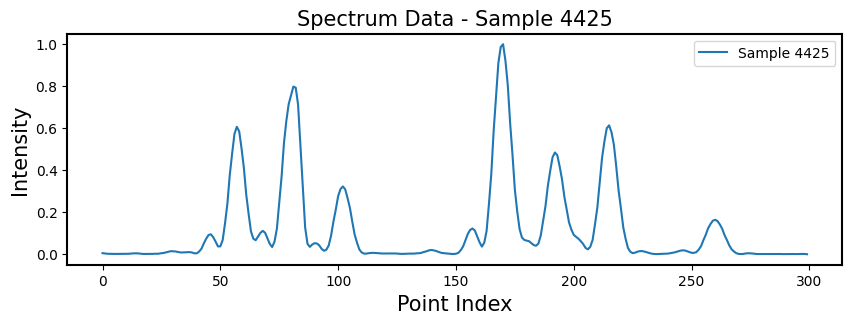

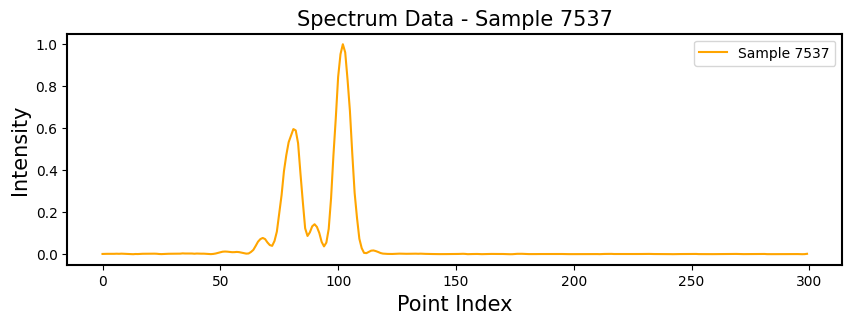

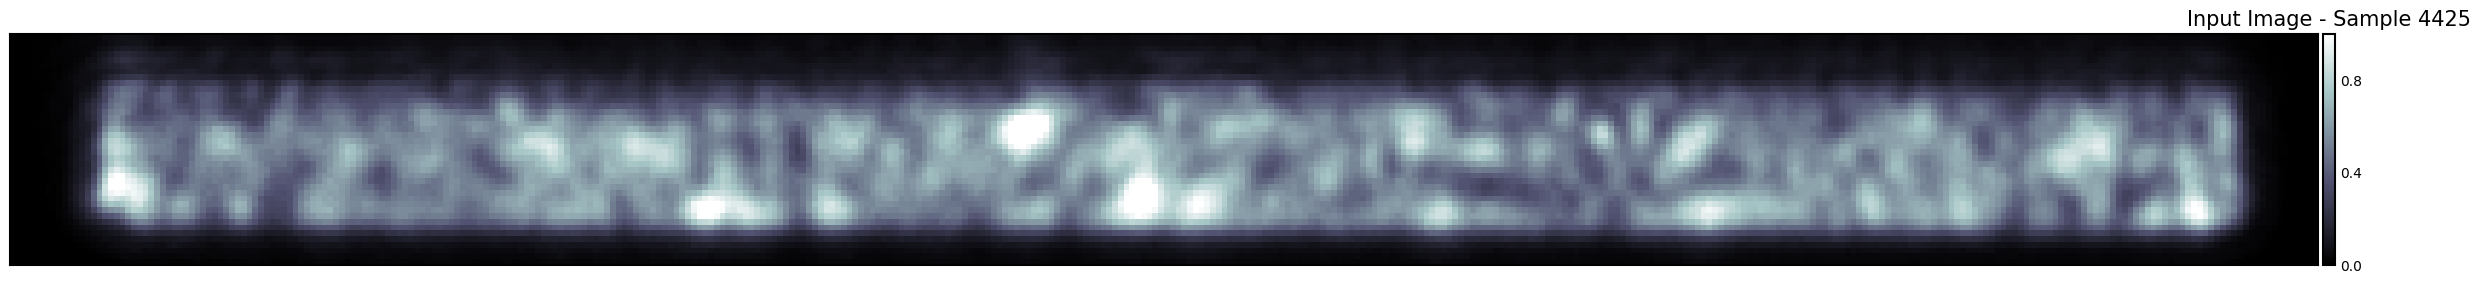

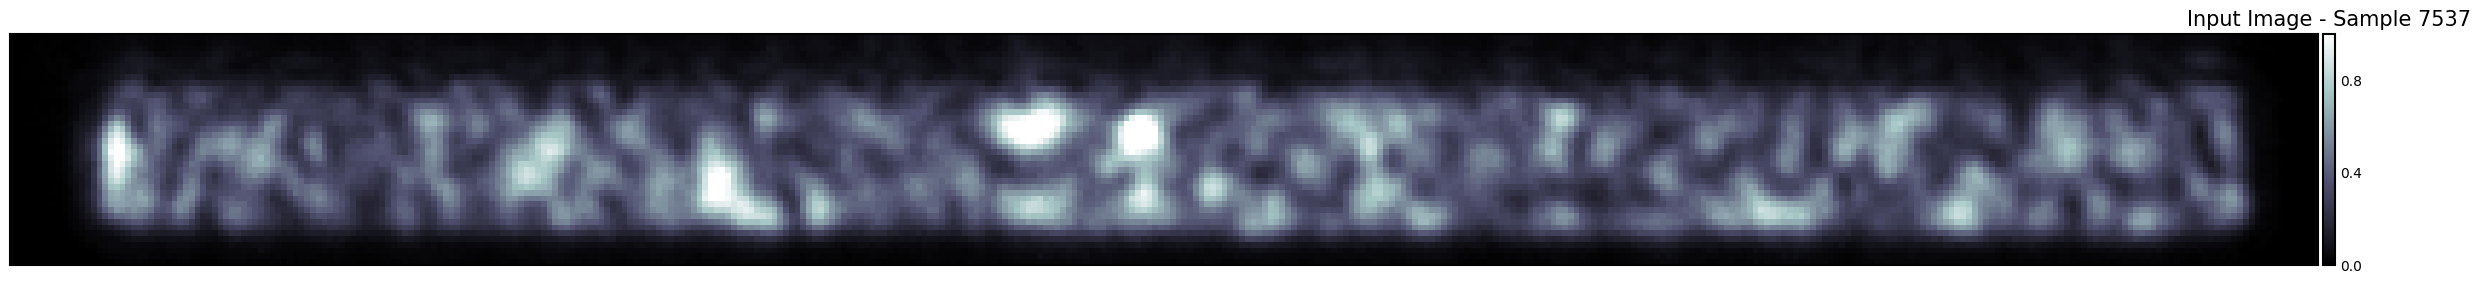

In [7]:
# Dataset Visualization (in English)
import random

# Select two random samples
sample1 = random.randint(0, x_dataset.shape[0] - 1)
sample2 = random.randint(0, x_dataset.shape[0] - 1)

print(f"Randomly selected sample indices: {sample1}, {sample2}")
print(f"y_dataset shape: {y_dataset.shape}")

# Extract wavelength and spectrum (compatible with y_dataset containing only one row)
def extract_wavelength_and_spectrum(y_dataset, sample_idx):
    """Extract wavelength and spectrum according to the shape of y_dataset"""
    # If y_dataset is 3D and the second dimension is 2, extract as specified
    if y_dataset.ndim == 3 and y_dataset.shape[1] == 2:
        wavelength = y_dataset[sample_idx, 0, :]
        spectrum = y_dataset[sample_idx, 1, :]
    else:
        # Assume wavelength is stored separately, only extract spectrum (for legacy format)
        wavelength = None
        spectrum = y_dataset[sample_idx, ...].squeeze()
    return wavelength, spectrum

x_ax1, spectrum1 = extract_wavelength_and_spectrum(y_dataset, sample1)
x_ax2, spectrum2 = extract_wavelength_and_spectrum(y_dataset, sample2)

# 帮你确保横坐标为wavelength
plt.rcParams['figure.figsize'] = [10, 3]
if x_ax1 is not None:
    plt.plot(x_ax1, spectrum1, label=f'Sample {sample1}')
    plt.xlabel('Wavelength')
else:
    plt.plot(np.arange(len(spectrum1)), spectrum1, label=f'Sample {sample1}')
    plt.xlabel('Point Index')
plt.title(f'Spectrum Data - Sample {sample1}')
plt.ylabel('Intensity')
plt.legend()
plt.show()

plt.rcParams['figure.figsize'] = [10, 3]
if x_ax2 is not None:
    plt.plot(x_ax2, spectrum2, label=f'Sample {sample2}', color='orange')
    plt.xlabel('Wavelength')
else:
    plt.plot(np.arange(len(spectrum2)), spectrum2, label=f'Sample {sample2}', color='orange')
    plt.xlabel('Point Index')
plt.title(f'Spectrum Data - Sample {sample2}')
plt.ylabel('Intensity')
plt.legend()
plt.show()

# Visualize input images
plt.rcParams['figure.figsize'] = [30, 20]
isns.imshow(x_dataset[sample1, :, :], robust=False, perc=(1, 99), cmap='bone')
plt.title(f'Input Image - Sample {sample1}')
plt.show()

isns.imshow(x_dataset[sample2, :, :], robust=False, perc=(1, 99), cmap='bone')
plt.title(f'Input Image - Sample {sample2}')
plt.show()


# ResNet


In [8]:
import os
import gc
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import logging

# ==== 问题诊断与解决辅助输出 ====
def check_data_loaded(x, y):
    try:
        assert x is not None and y is not None
        print("✅ [数据] x_dataset.shape:", x.shape, "| y_dataset.shape:", y.shape)
    except Exception as e:
        print("❌ [数据] x_dataset或y_dataset未正确定义！错误：", e)
        raise

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

# ==== 请设置你的数据集保存路径 ds_dir, 若未定义会出错 ====
try:
    save_dir = os.path.join(ds_dir, 'Resnet_training_checkpoints/')
except Exception:
    print("❌ ds_dir 未定义。请定义数据保存路径 ds_dir = '你的路径'")
    raise
os.makedirs(save_dir, exist_ok=True)

# ==== 数据检查 ====
check_data_loaded(x_dataset, y_dataset)

# ----------- 训练曲线绘图回调 -----------
class PlotCallback(tf.keras.callbacks.Callback):
    def __init__(self, save_dir, plot_frequency=10):
        super().__init__()
        self.save_dir = save_dir
        self.plot_frequency = plot_frequency
        self.train_loss, self.val_loss = [], []
        self.train_mse,  self.val_mse  = [], []
        self.train_mae,  self.val_mae  = [], []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.train_loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.train_mse.append(logs.get('mse'))
        self.val_mse.append(logs.get('val_mse'))
        self.train_mae.append(logs.get('mae'))
        self.val_mae.append(logs.get('val_mae'))
        if (epoch + 1) % self.plot_frequency == 0:
            ep = range(1, len(self.train_loss) + 1)
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(ep, self.train_loss, label='Train Loss')
            if self.val_loss[0] is not None:
                plt.plot(ep, self.val_loss, label='Val Loss')
            plt.title(f'Loss (Epoch {epoch + 1})')
            plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
            plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2)
            plt.plot(ep, self.train_mae, label='Train MAE')
            if self.val_mae[0] is not None:
                plt.plot(ep, self.val_mae, label='Val MAE')
            plt.title('MAE')
            plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
            plt.tight_layout()
            save_path = os.path.join(self.save_dir, f'epoch_{epoch + 1}_performance.png')
            plt.savefig(save_path, dpi=100)
            plt.close()
            print(f"\n[PlotCallback] saved: {save_path}")

# ----------- 数据准备 -----------
# x_dataset (N, 40, 400) float32, [0,1]
# y_dataset 可能为 (N, 300, 1) 或 (N, 2, 300) (含 wavelength)
if x_dataset.ndim == 3:
    x_exp = np.expand_dims(x_dataset, axis=-1).astype(np.float32)   # (N,40,400,1)
else:
    x_exp = x_dataset.astype(np.float32)

if y_dataset.ndim == 3 and y_dataset.shape[1] == 2:
    y_exp = y_dataset[:, 1, :].astype(np.float32)                   # 取光谱通道
elif y_dataset.ndim == 3 and y_dataset.shape[-1] == 1:
    y_exp = y_dataset.squeeze(-1).astype(np.float32)
else:
    y_exp = y_dataset.astype(np.float32)

print(f"X shape: {x_exp.shape}, dtype: {x_exp.dtype}, range=[{x_exp.min():.3f},{x_exp.max():.3f}]")
print(f"Y shape: {y_exp.shape}, dtype: {y_exp.dtype}, range=[{y_exp.min():.3f},{y_exp.max():.3f}]")

# 训练超参数
divide_ratio   = 0.85
batch_size     = 64        
epochs         = 1000
patience       = 100
plot_frequency = 10
LR             = 1e-4

print("🔀 划分训练集 / 验证集...")
try:
    train_x, val_x, train_y, val_y = train_test_split(
        x_exp, y_exp, test_size=1 - divide_ratio, random_state=42
    )
except Exception as e:
    print("❌ 数据集划分出错，请检查 x_exp 和 y_exp:", e)
    raise

trainset = (tf.data.Dataset.from_tensor_slices((train_x, train_y))
            .shuffle(len(train_x), reshuffle_each_iteration=True)
            .batch(batch_size).cache().prefetch(tf.data.AUTOTUNE))
valset = (tf.data.Dataset.from_tensor_slices((val_x, val_y))
          .batch(batch_size).cache().prefetch(tf.data.AUTOTUNE))

print(f"✅ 训练: {len(train_x)} | 验证: {len(val_x)} | batch={batch_size}")

# ----------- ResNet 架构 -----------
try: del nn_model
except: pass
gc.collect()
tf.keras.backend.clear_session()

INPUT_SHAPE = (x_exp.shape[1], x_exp.shape[2], 1)   # (40, 400, 1)
try:
    OUTPUT_LEN  = y_exp.shape[1]                        # 300
except Exception:
    print("❌ y_exp.shape 出错, 当前y_exp.shape=", y_exp.shape)
    raise

def residual_block(x, filters, kernel_size=(3, 3), stride=1):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_mmi(input_shape, output_length):
    inputs = layers.Input(shape=input_shape, name='input_image')
    x = layers.Conv2D(32, (7, 7), strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64,  stride=1)
    x = residual_block(x, 64,  stride=1)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    x = layers.Conv2D(256, (1, 1), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(output_length, activation='sigmoid', name='spectrum_out')(x)
    return models.Model(inputs=inputs, outputs=outputs, name="ResNet_MMI")

# ==== 模型训练 ====
def train_main():
    nn_model = build_resnet_mmi(INPUT_SHAPE, OUTPUT_LEN)
    print("\n🏗️ ResNet 模型结构:")
    nn_model.summary()
    print(f"\n总参数量: {nn_model.count_params():,}")

    # ----------- 编译与训练 -----------
    opt = optimizers.Adam(learning_rate=LR)
    nn_model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mse', 'mae']
    )

    callbacks_list = [
        EarlyStopping(
            monitor='val_mse', mode='min',
            patience=patience, restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(save_dir, 'best_model.keras'),
            monitor='val_mse', save_best_only=True, mode='min', verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_mse', mode='min',
            factor=0.5, patience=25, min_lr=1e-6, verbose=1
        ),
        PlotCallback(save_dir=save_dir, plot_frequency=plot_frequency)
    ]

    print("🚀 开始训练 ResNet ...")
    try:
        start_time = time.time()
        nn_history = nn_model.fit(
            trainset,
            validation_data=valset,
            epochs=epochs,
            verbose=2,
            callbacks=callbacks_list
        )
        end_time = time.time()
        print(f"\n🎉 训练完成! 耗时: {end_time - start_time:.1f} 秒")
    except Exception as e:
        print("❌ 训练异常：", e)
        raise

    best_model_path = os.path.join(save_dir, 'best_model.keras')
    if os.path.exists(best_model_path):
        print(f"\n💾 最佳模型已保存: {best_model_path}")

# 主入口
try:
    train_main()
except Exception as e:
    print("\n==== 训练失败诊断建议 ====")
    print("1. 检查 x_dataset/y_dataset 是否已加载为 numpy array。")
    print("2. 检查 x_dataset shape是否为 (N,40,400)，y_dataset shape是否为 (N,300) 或 (N,2,300) 或 (N,300,1)。")
    print("3. 检查 ds_dir 是否已正确定义为你的工作目录路径。")
    print("4. 检查环境的CUDA/cuDNN是否配置正确。")
    print("5. 如有其它报错，请贴出堆栈信息。")
    print(f"异常原因: {e}")

✅ [数据] x_dataset.shape: (8959, 40, 400) | y_dataset.shape: (8959, 300)
X shape: (8959, 40, 400, 1), dtype: float32, range=[0.000,1.000]
Y shape: (8959, 300), dtype: float32, range=[0.000,1.000]
🔀 划分训练集 / 验证集...
✅ 训练: 7615 | 验证: 1344 | batch=64

🏗️ ResNet 模型结构:


Model: "ResNet_MMI"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 40, 400,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 20, 200,   │      1,600 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 200,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 20, 200,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 20, 200,   │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 200,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 20, 200,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 200,   │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 200,   │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 200,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 200,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 200,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 20, 200,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 200,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 200,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 20, 200,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 200,   │     36,928 │ activation_3[0][

 Total params: 21,282,988 (81.19 MB)

 Trainable params: 21,273,324 (81.15 MB)

 Non-trainable params: 9,664 (37.75 KB)


总参数量: 21,282,988
🚀 开始训练 ResNet ...
Epoch 1/1000
119/119 - 57s - 476ms/step - loss: 0.0469 - mae: 0.1123 - mse: 0.0469 - val_loss: 0.0299 - val_mae: 0.0964 - val_mse: 0.0299 - learning_rate: 1.0000e-04
Epoch 2/1000
119/119 - 3s - 29ms/step - loss: 0.0139 - mae: 0.0616 - mse: 0.0139 - val_loss: 0.0341 - val_mae: 0.0823 - val_mse: 0.0341 - learning_rate: 1.0000e-04
Epoch 3/1000
119/119 - 3s - 29ms/step - loss: 0.0094 - mae: 0.0519 - mse: 0.0094 - val_loss: 0.0320 - val_mae: 0.0815 - val_mse: 0.0320 - learning_rate: 1.0000e-04
Epoch 4/1000
119/119 - 5s - 40ms/step - loss: 0.0073 - mae: 0.0466 - mse: 0.0073 - val_loss: 0.0269 - val_mae: 0.0787 - val_mse: 0.0269 - learning_rate: 1.0000e-04
Epoch 5/1000
119/119 - 5s - 40ms/step - loss: 0.0059 - mae: 0.0429 - mse: 0.0059 - val_loss: 0.0105 - val_mae: 0.0597 - val_mse: 0.0105 - learning_rate: 1.0000e-04
Epoch 6/1000
119/119 - 5s - 40ms/step - loss: 0.0050 - mae: 0.0399 - mse: 0.0050 - val_loss: 0.0028 - val_mae: 0.0322 - val_mse: 0.0028 - lear

## testval

In [9]:
from sklearn.model_selection import train_test_split

# ⏳ 如果 x_dataset 和 y_dataset 还没加载，请先加载你的数据
# 例如从 h5 文件中加载
# x_dataset, y_dataset = ...

# ✅ 设置划分比例
divide_ratio = 0.85  # 训练集比例

# 🔀 执行划分
train_x, val_x, train_y, val_y = train_test_split(
    x_dataset, y_dataset,
    test_size=1 - divide_ratio,
    random_state=42
)

print(f"✅ 划分完成：")
print(f"train_x: {train_x.shape}, train_y: {train_y.shape}")
print(f"val_x:   {val_x.shape}, val_y:   {val_y.shape}")


✅ 划分完成：
train_x: (7615, 40, 400), train_y: (7615, 300)
val_x:   (1344, 40, 400), val_y:   (1344, 300)


✅ Validation set shapes: X: (1344, 40, 400, 1) | Y: (1344, 300)
📦 Loading model: /content/drive/MyDrive/ucsc/MMI/8um/Resnet_training_checkpoints/best_model.keras
✅ Model loaded successfully.
🔍 Predicting on the validation set ...
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

📊 Validation MSE: 0.000070
📊 Validation MAE: 0.002908


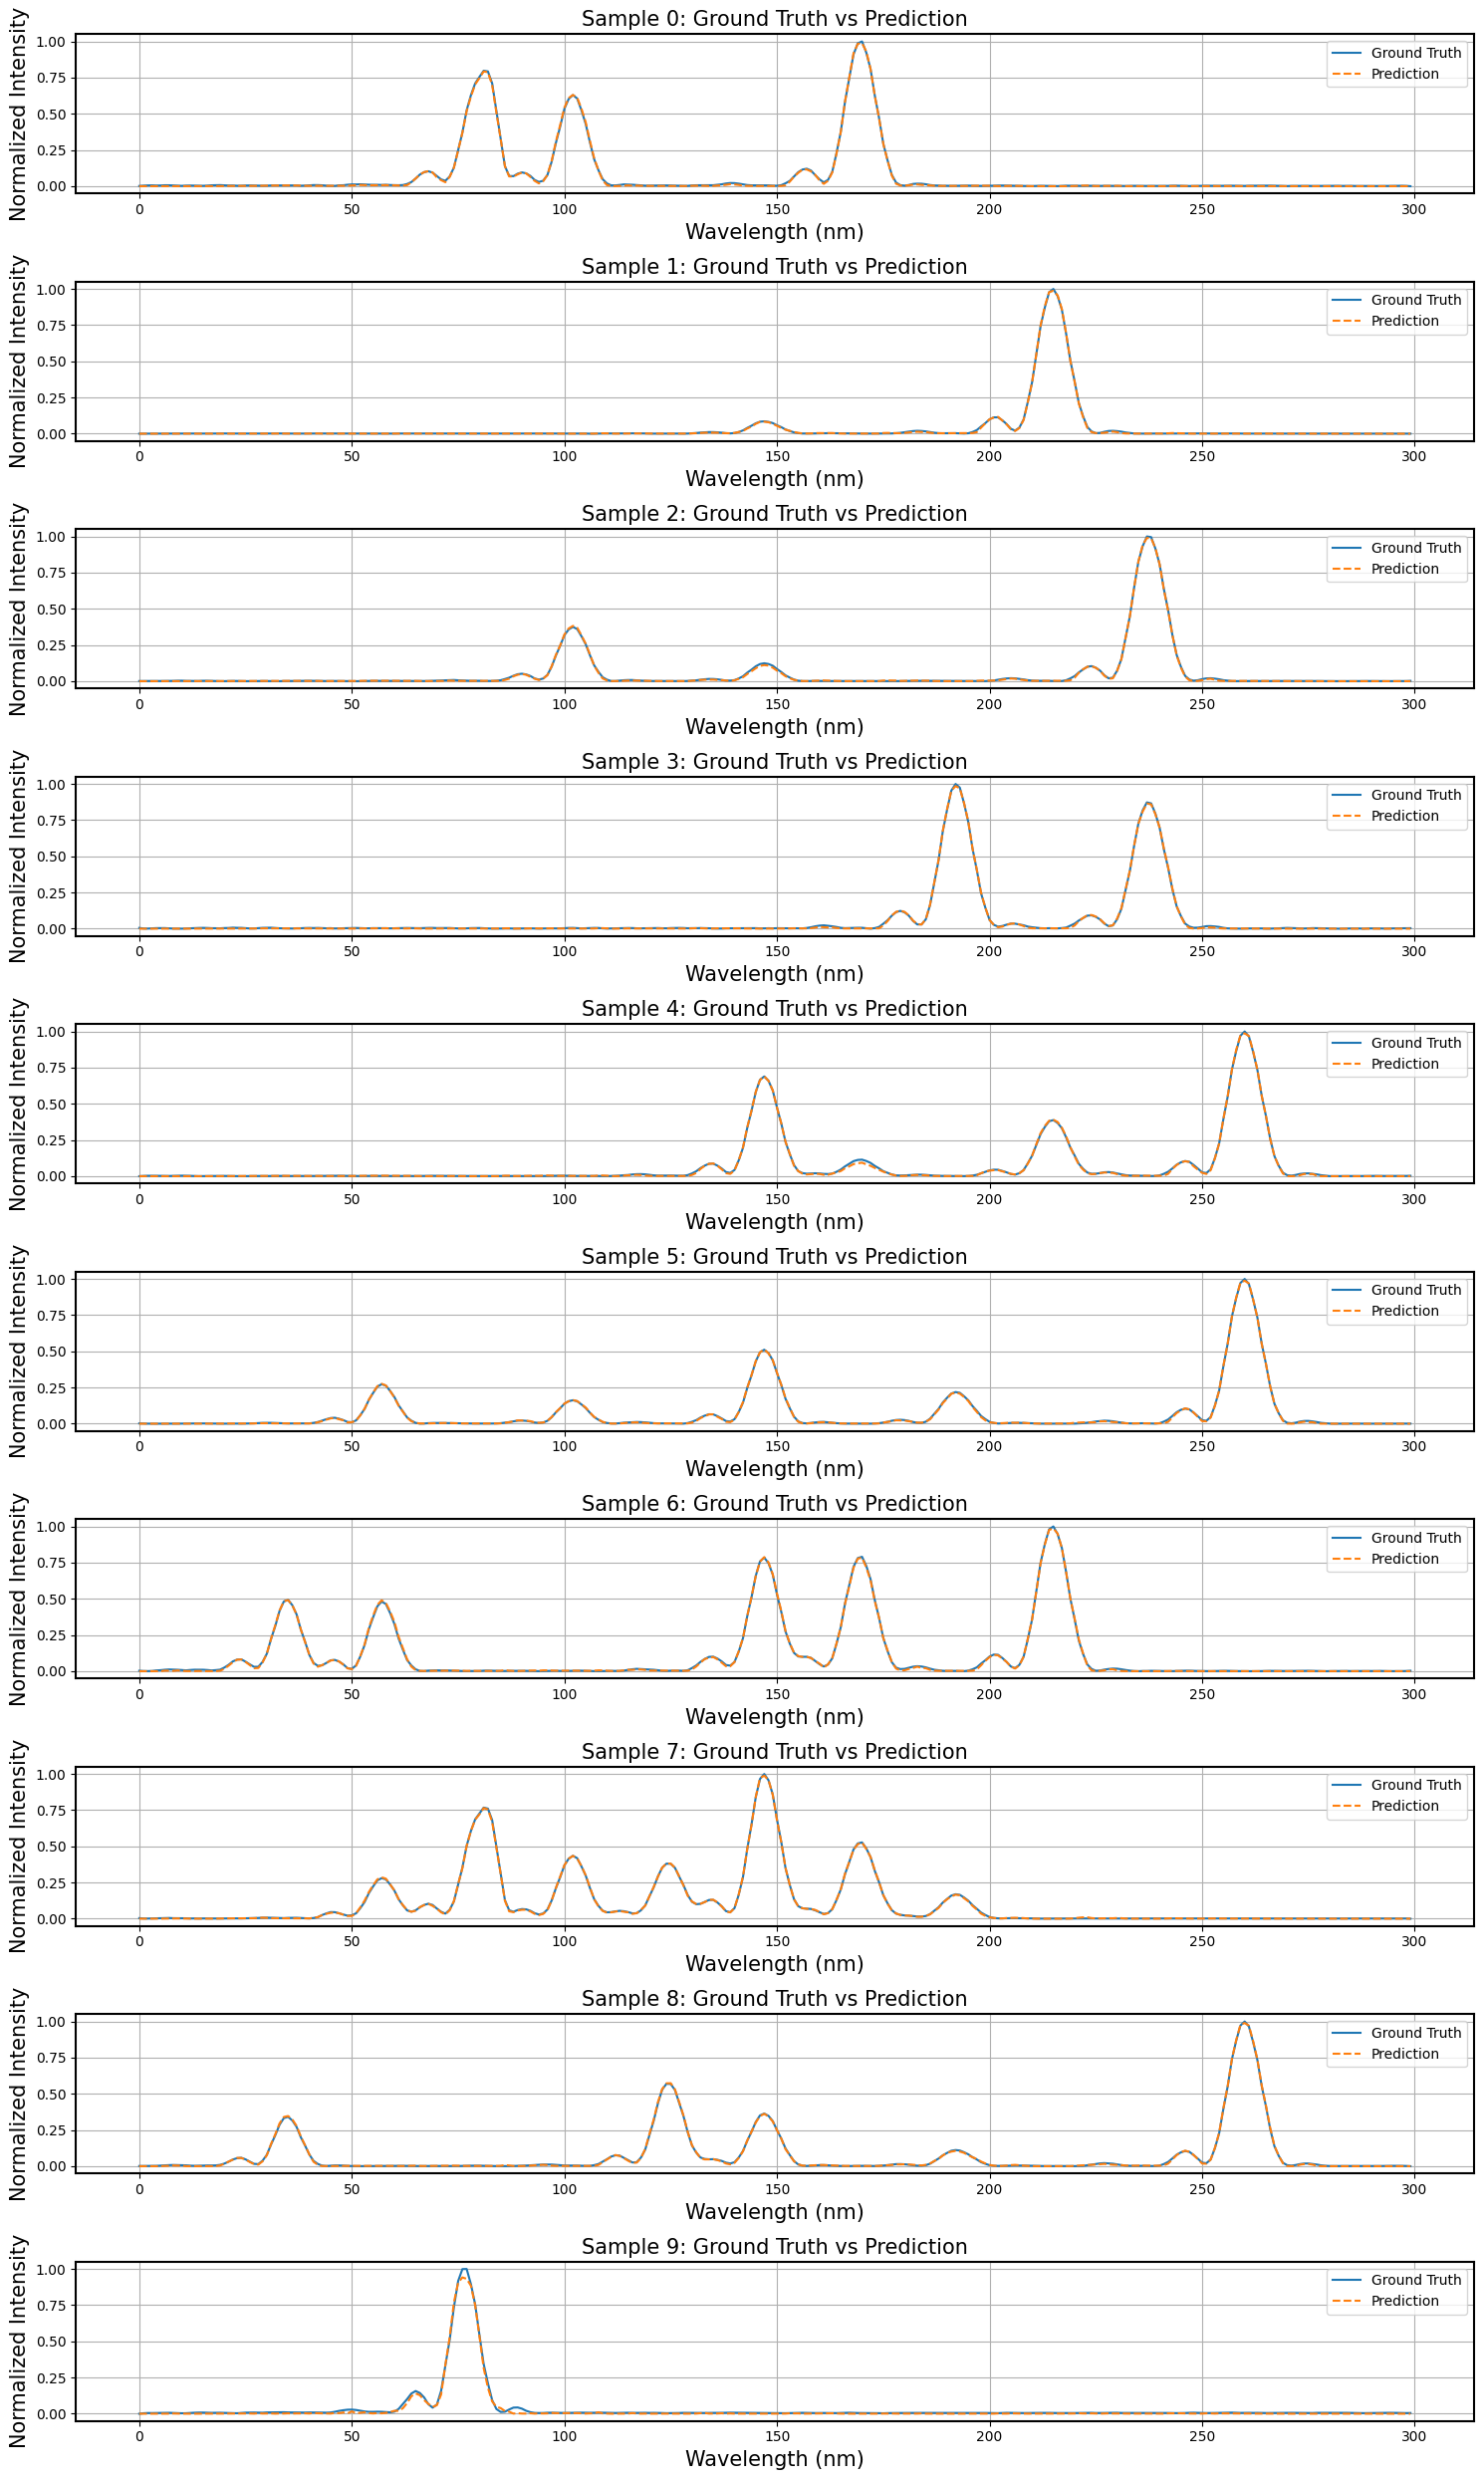

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ===== Parameter settings: keep consistent with the main training phase =====
# Note: save_dir should be EXACTLY the same as during training
save_dir = os.path.join(ds_dir, 'Resnet_training_checkpoints/')
best_model_path = os.path.join(save_dir, 'best_model.keras')

# Batch size should be similar to training (can use a larger batch for validation to speed up)
batch_size = 64

# ===== Data preparation: process the data the same way as during training =====
# x_dataset shape: (N, 40, 400) or (N, 40, 400, 1)
# y_dataset shape: (N, 300) or (N, 2, 300) or (N, 300, 1)
if x_dataset.ndim == 3:
    val_x_pred = np.expand_dims(val_x, axis=-1).astype(np.float32)   # (N, 40, 400, 1)
else:
    val_x_pred = val_x.astype(np.float32)

if val_y.ndim == 3 and val_y.shape[1] == 2:
    val_y_pred = val_y[:, 1, :].astype(np.float32)
elif val_y.ndim == 3 and val_y.shape[-1] == 1:
    val_y_pred = val_y.squeeze(-1).astype(np.float32)
else:
    val_y_pred = val_y.astype(np.float32)

print(f"✅ Validation set shapes: X: {val_x_pred.shape} | Y: {val_y_pred.shape}")

# ===== Load the best model =====
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"❌ Model file not found: {best_model_path}")
print(f"📦 Loading model: {best_model_path}")
model = load_model(best_model_path)
print("✅ Model loaded successfully.")

# ===== Prediction =====
print("🔍 Predicting on the validation set ...")
predictions = model.predict(val_x_pred, batch_size=batch_size)
# Model output shape: (N, 300)

# ===== Ensure the prediction and label shapes are consistent =====
if predictions.ndim == 3 and predictions.shape[-1] == 1:
    predictions = np.squeeze(predictions)
if val_y_pred.ndim == 3 and val_y_pred.shape[-1] == 1:
    val_y_pred = np.squeeze(val_y_pred)
if predictions.shape != val_y_pred.shape:
    raise ValueError(f"Prediction shape {predictions.shape} does not match label shape {val_y_pred.shape}")

# ===== Calculate error metrics =====
mse = np.mean((predictions - val_y_pred) ** 2)
mae = np.mean(np.abs(predictions - val_y_pred))
print(f"\n📊 Validation MSE: {mse:.6f}")
print(f"📊 Validation MAE: {mae:.6f}")

# ===== Visualization: plot the first few sample results =====
n_plot = min(10, val_y_pred.shape[0])
plt.figure(figsize=(15, n_plot * 2.5))
for i in range(n_plot):
    # Handle wavelength axis as before
    if 'wavelength_base' in locals():
        wavelengths_to_plot = wavelength_base
    else:
        wavelengths_to_plot = np.arange(val_y_pred.shape[1])
    gt = val_y_pred[i]
    pd = predictions[i]
    if wavelengths_to_plot.shape[0] != gt.shape[0]:
        raise ValueError(f"wavelengths (shape {wavelengths_to_plot.shape}) and spectrum (shape {gt.shape}) do not match!")
    plt.subplot(n_plot, 1, i+1)
    plt.plot(wavelengths_to_plot, gt, label='Ground Truth')
    plt.plot(wavelengths_to_plot, pd, '--', label='Prediction')
    plt.title(f'Sample {i}: Ground Truth vs Prediction')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Normalized Intensity')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()


## testset_single

Loading: /content/drive/MyDrive/ucsc/MMI/8um/single_test.h5
Keys: ['img', 'img_filenames', 'labels', 'osa', 'osa_filenames', 'source_indices', 'wavelength']
test_x: (51, 40, 400, 1), test_y: (51, 300)
Loading model: /content/drive/MyDrive/ucsc/MMI/8um/Resnet_training_checkpoints/best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Test MSE: 0.001349
Test MAE: 0.006851
  [0] 620nm: MAE=0.0035
  [1] 621nm: MAE=0.0038
  [2] 622nm: MAE=0.0039
  [3] 623nm: MAE=0.0037
  [4] 624nm: MAE=0.0040
  [5] 625nm: MAE=0.0070
  [6] 626nm: MAE=0.0311
  [7] 627nm: MAE=0.0035
  [8] 628nm: MAE=0.0071
  [9] 629nm: MAE=0.0316


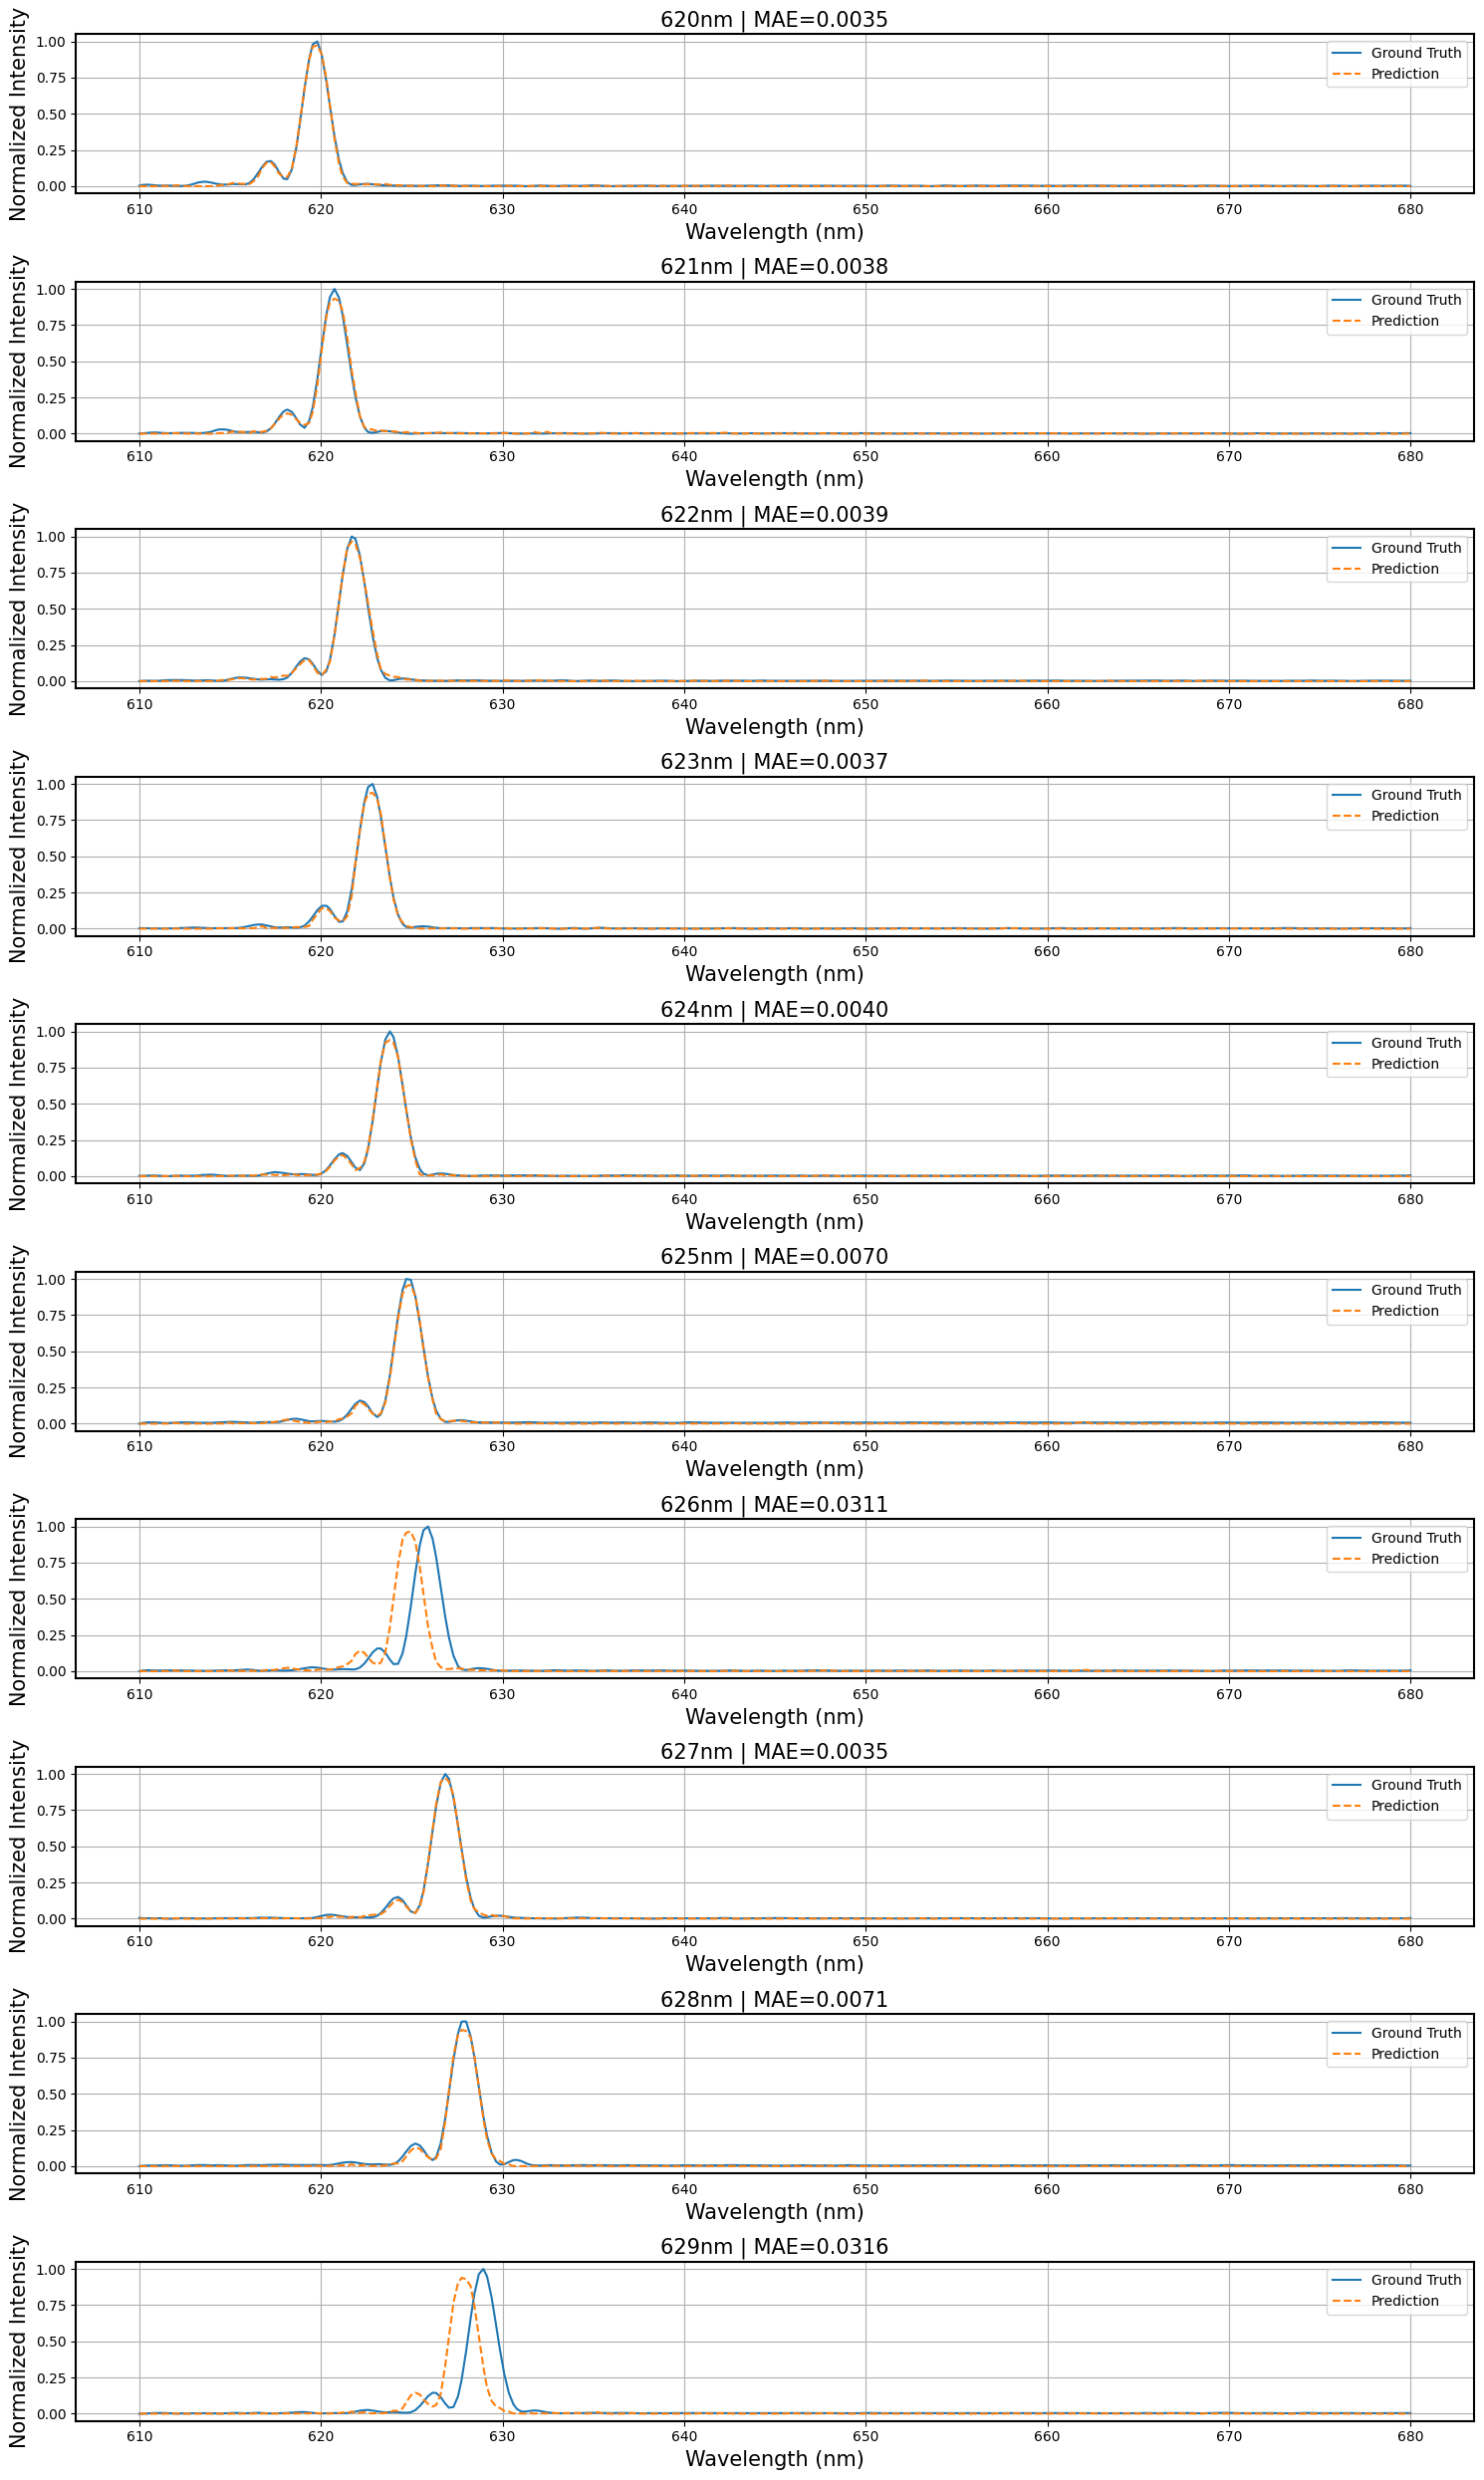

In [13]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ===== 路径 =====
test_file = os.path.join(ds_dir, "single_test.h5")
best_model_path = os.path.join(ds_dir, "Resnet_training_checkpoints", "best_model.keras")
batch_size = 64

# ===== 1. 加载 single_test.h5（注意：结构与 train.h5 不同）=====
with h5py.File(test_file, "r") as hf:
    print(f"Loading: {test_file}")
    print(f"Keys: {list(hf.keys())}")

    test_x = hf["img"][:].astype(np.float32)              # (51, 40, 400)
    test_y = hf["osa"][:].squeeze(-1).astype(np.float32) # (51, 300)
    wavelength = hf["wavelength"][0]                    # 所有样本波长相同
    labels = [
        x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
        for x in hf["labels"][:]
    ]

# 与训练一致：加 channel 维 -> (N, 40, 400, 1)
if test_x.ndim == 3:
    test_x = np.expand_dims(test_x, axis=-1)

print(f"test_x: {test_x.shape}, test_y: {test_y.shape}")

# ===== 2. 加载最佳模型 =====
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model not found: {best_model_path}")

print(f"Loading model: {best_model_path}")
model = load_model(best_model_path)

# ===== 3. 预测 =====
predictions = model.predict(test_x, batch_size=batch_size, verbose=1)
if predictions.ndim == 3 and predictions.shape[-1] == 1:
    predictions = predictions.squeeze(-1)

# ===== 4. 指标 =====
mse = np.mean((predictions - test_y) ** 2)
mae = np.mean(np.abs(predictions - test_y))
print(f"\nTest MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")

per_sample_mae = np.mean(np.abs(predictions - test_y), axis=1)
for i in range(min(10, len(labels))):
    print(f"  [{i}] {labels[i]}: MAE={per_sample_mae[i]:.4f}")

# ===== 5. 可视化 =====
n_plot = min(10, len(test_y))
plt.figure(figsize=(15, n_plot * 2.5))
for i in range(n_plot):
    plt.subplot(n_plot, 1, i + 1)
    plt.plot(wavelength, test_y[i], label="Ground Truth")
    plt.plot(wavelength, predictions[i], "--", label="Prediction")
    plt.title(f"{labels[i]} | MAE={per_sample_mae[i]:.4f}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Intensity")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

Loading: /content/drive/MyDrive/ucsc/MMI/8um/multi_test.h5
Keys: ['img', 'img_filenames', 'labels', 'osa', 'osa_filenames', 'source_indices', 'wavelength']
test_x: (500, 40, 400, 1), test_y: (500, 300)
Loading model: /content/drive/MyDrive/ucsc/MMI/8um/Resnet_training_checkpoints/best_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 443ms/step

Test MSE: 0.000015
Test MAE: 0.002636
  [0] group_1: MAE=0.0021
  [1] group_2: MAE=0.0019
  [2] group_3: MAE=0.0032
  [3] group_4: MAE=0.0025
  [4] group_5: MAE=0.0035
  [5] group_6: MAE=0.0033
  [6] group_7: MAE=0.0029
  [7] group_8: MAE=0.0022
  [8] group_9: MAE=0.0018
  [9] group_10: MAE=0.0019


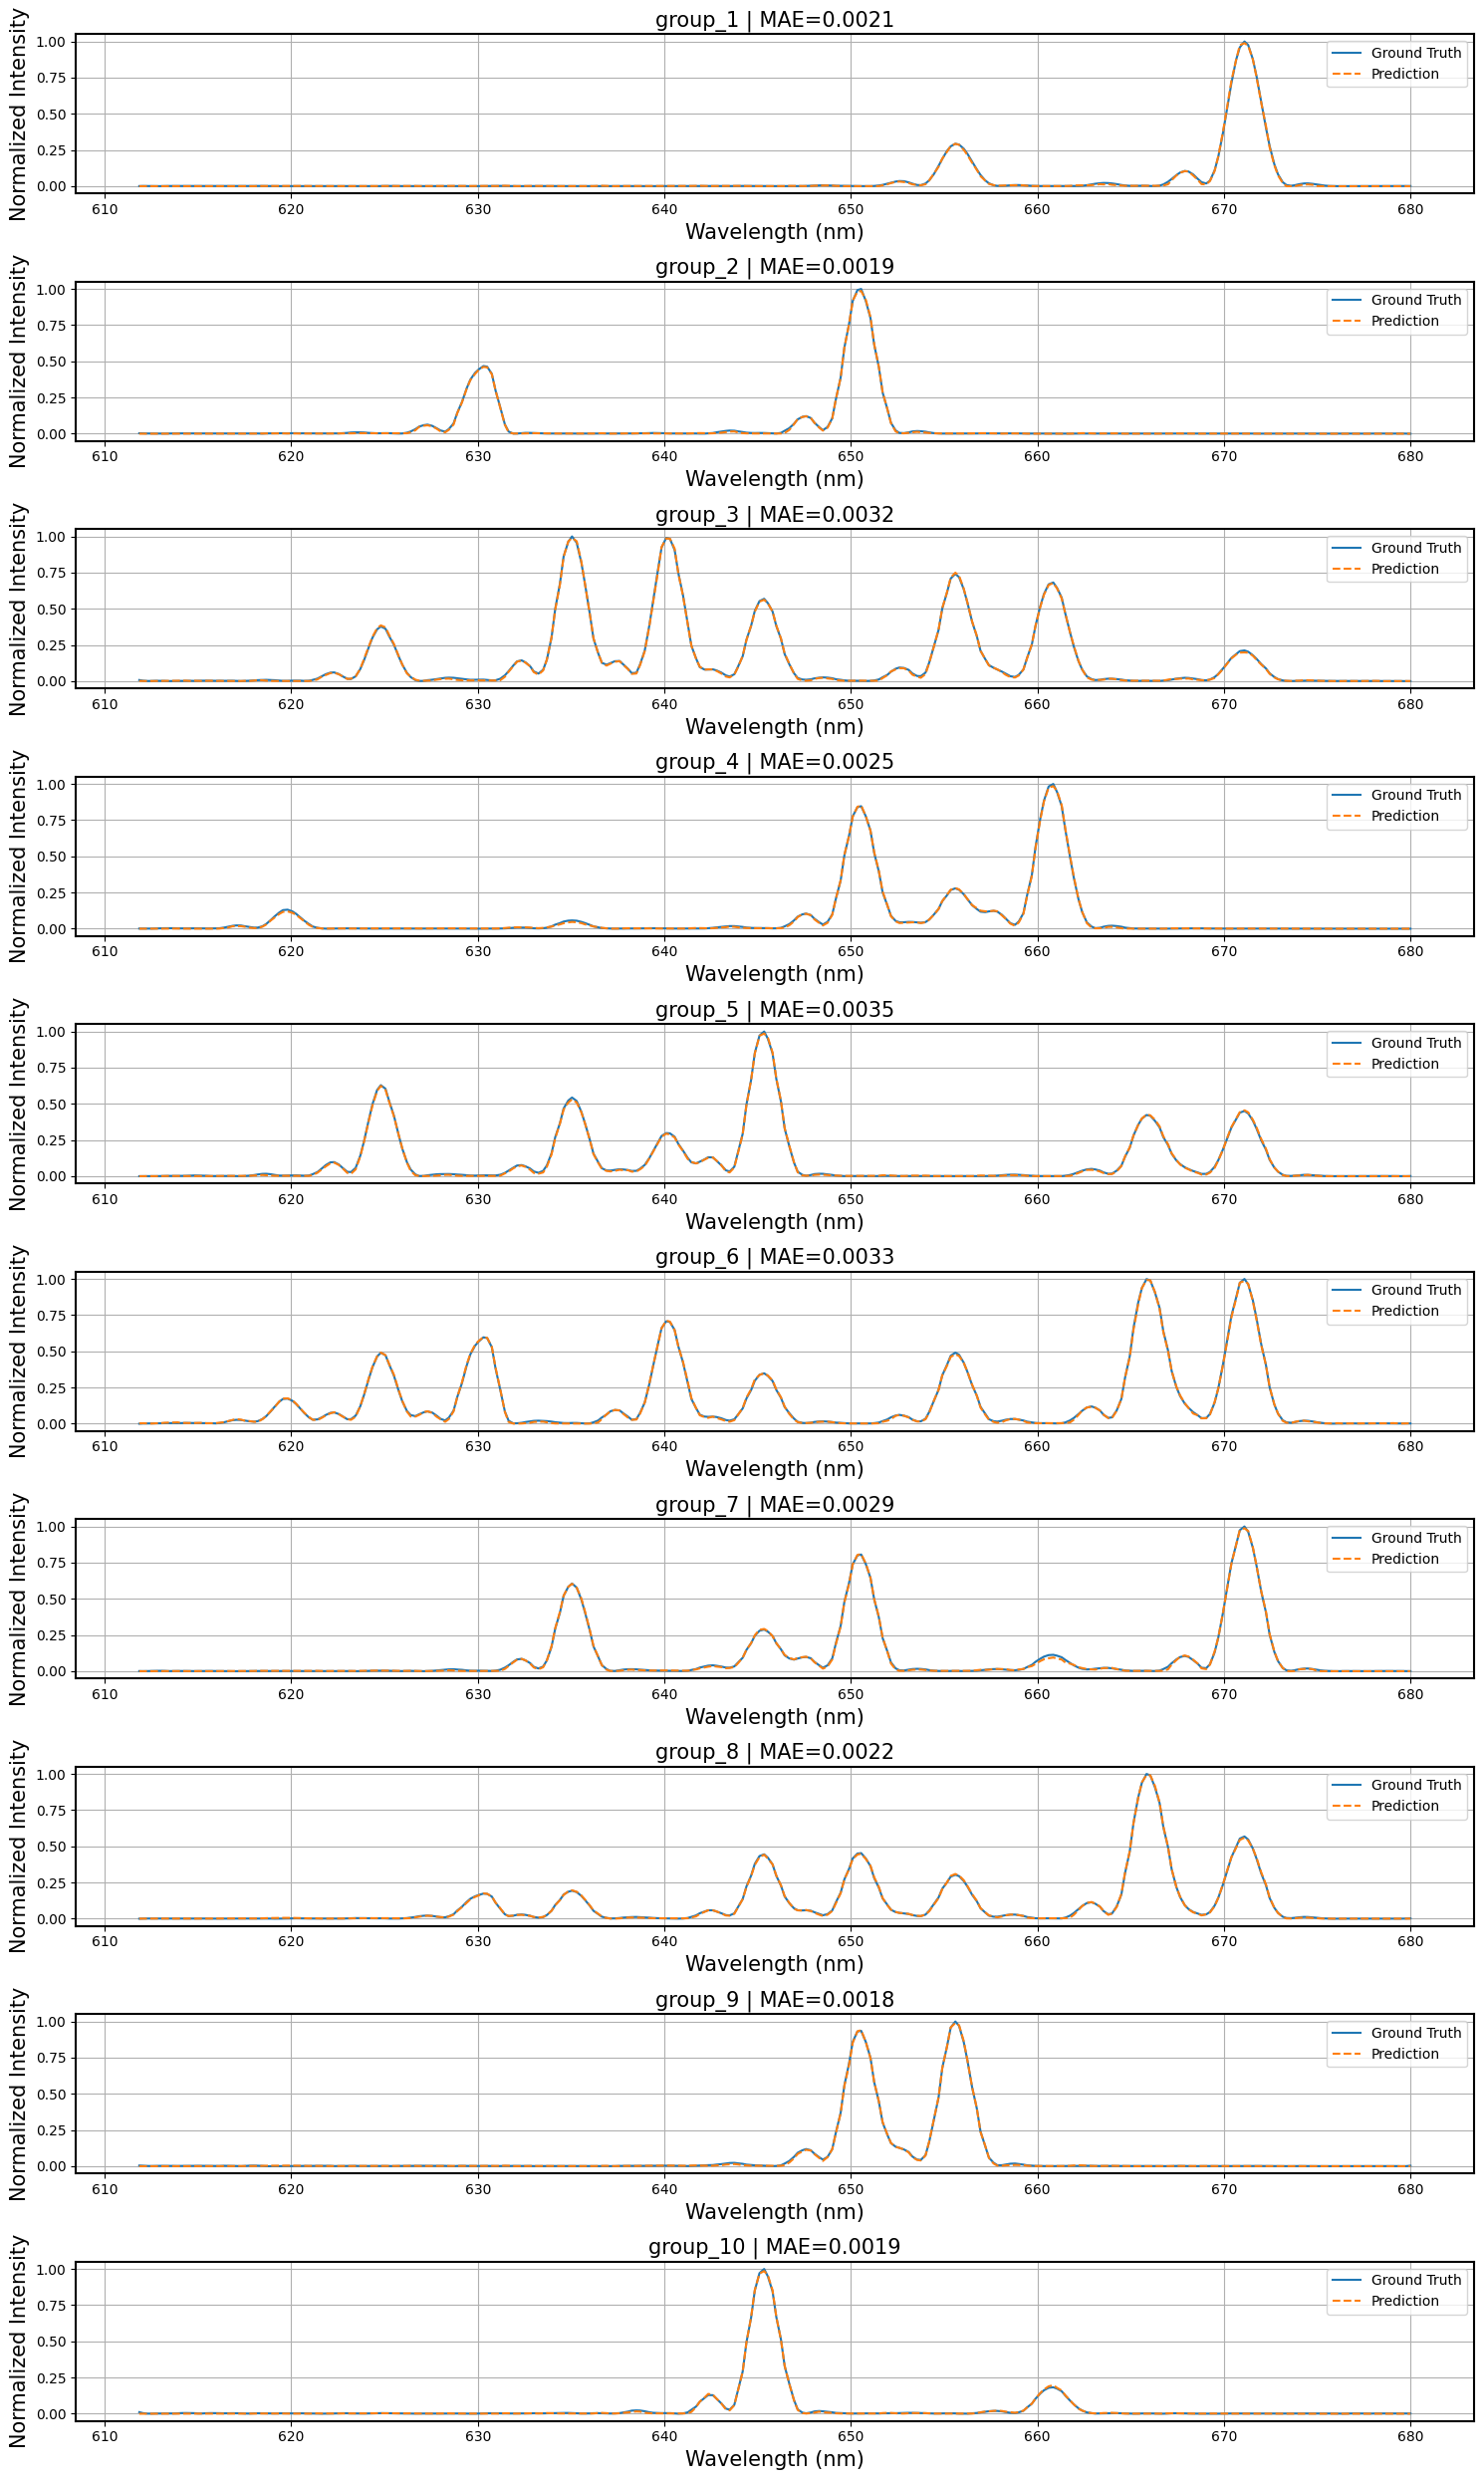

In [14]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ===== 路径 =====
test_file = os.path.join(ds_dir, "multi_test.h5")
best_model_path = os.path.join(ds_dir, "Resnet_training_checkpoints", "best_model.keras")
batch_size = 64

# ===== 1. 加载 multi_test.h5（注意：结构与 train.h5 不同）=====
with h5py.File(test_file, "r") as hf:
    print(f"Loading: {test_file}")
    print(f"Keys: {list(hf.keys())}")

    test_x = hf["img"][:].astype(np.float32)              # (51, 40, 400)
    test_y = hf["osa"][:].squeeze(-1).astype(np.float32) # (51, 300)
    wavelength = hf["wavelength"][0]                    # 所有样本波长相同
    labels = [
        x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
        for x in hf["labels"][:]
    ]

# 与训练一致：加 channel 维 -> (N, 40, 400, 1)
if test_x.ndim == 3:
    test_x = np.expand_dims(test_x, axis=-1)

print(f"test_x: {test_x.shape}, test_y: {test_y.shape}")

# ===== 2. 加载最佳模型 =====
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model not found: {best_model_path}")

print(f"Loading model: {best_model_path}")
model = load_model(best_model_path)

# ===== 3. 预测 =====
predictions = model.predict(test_x, batch_size=batch_size, verbose=1)
if predictions.ndim == 3 and predictions.shape[-1] == 1:
    predictions = predictions.squeeze(-1)

# ===== 4. 指标 =====
mse = np.mean((predictions - test_y) ** 2)
mae = np.mean(np.abs(predictions - test_y))
print(f"\nTest MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")

per_sample_mae = np.mean(np.abs(predictions - test_y), axis=1)
for i in range(min(10, len(labels))):
    print(f"  [{i}] {labels[i]}: MAE={per_sample_mae[i]:.4f}")

# ===== 5. 可视化 =====
n_plot = min(10, len(test_y))
plt.figure(figsize=(15, n_plot * 2.5))
for i in range(n_plot):
    plt.subplot(n_plot, 1, i + 1)
    plt.plot(wavelength, test_y[i], label="Ground Truth")
    plt.plot(wavelength, predictions[i], "--", label="Prediction")
    plt.title(f"{labels[i]} | MAE={per_sample_mae[i]:.4f}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Intensity")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

## test set 2

Loading: /content/drive/MyDrive/ucsc/MMI/8um/test2.h5
Keys: ['img', 'img_filenames', 'labels', 'osa', 'osa_filenames', 'peaks', 'wavelength']
test_x: (50, 40, 400, 1), test_y: (50, 300)
Loading model: /content/drive/MyDrive/ucsc/MMI/8um/Resnet_training_checkpoints/best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Test MSE: 0.004617
Test MAE: 0.045819
  [0] group_1: MAE=0.0164
  [1] group_2: MAE=0.0445
  [2] group_3: MAE=0.0800
  [3] group_4: MAE=0.0354
  [4] group_5: MAE=0.0485
  [5] group_6: MAE=0.0680
  [6] group_7: MAE=0.0339
  [7] group_8: MAE=0.0449
  [8] group_9: MAE=0.0304
  [9] group_10: MAE=0.0296


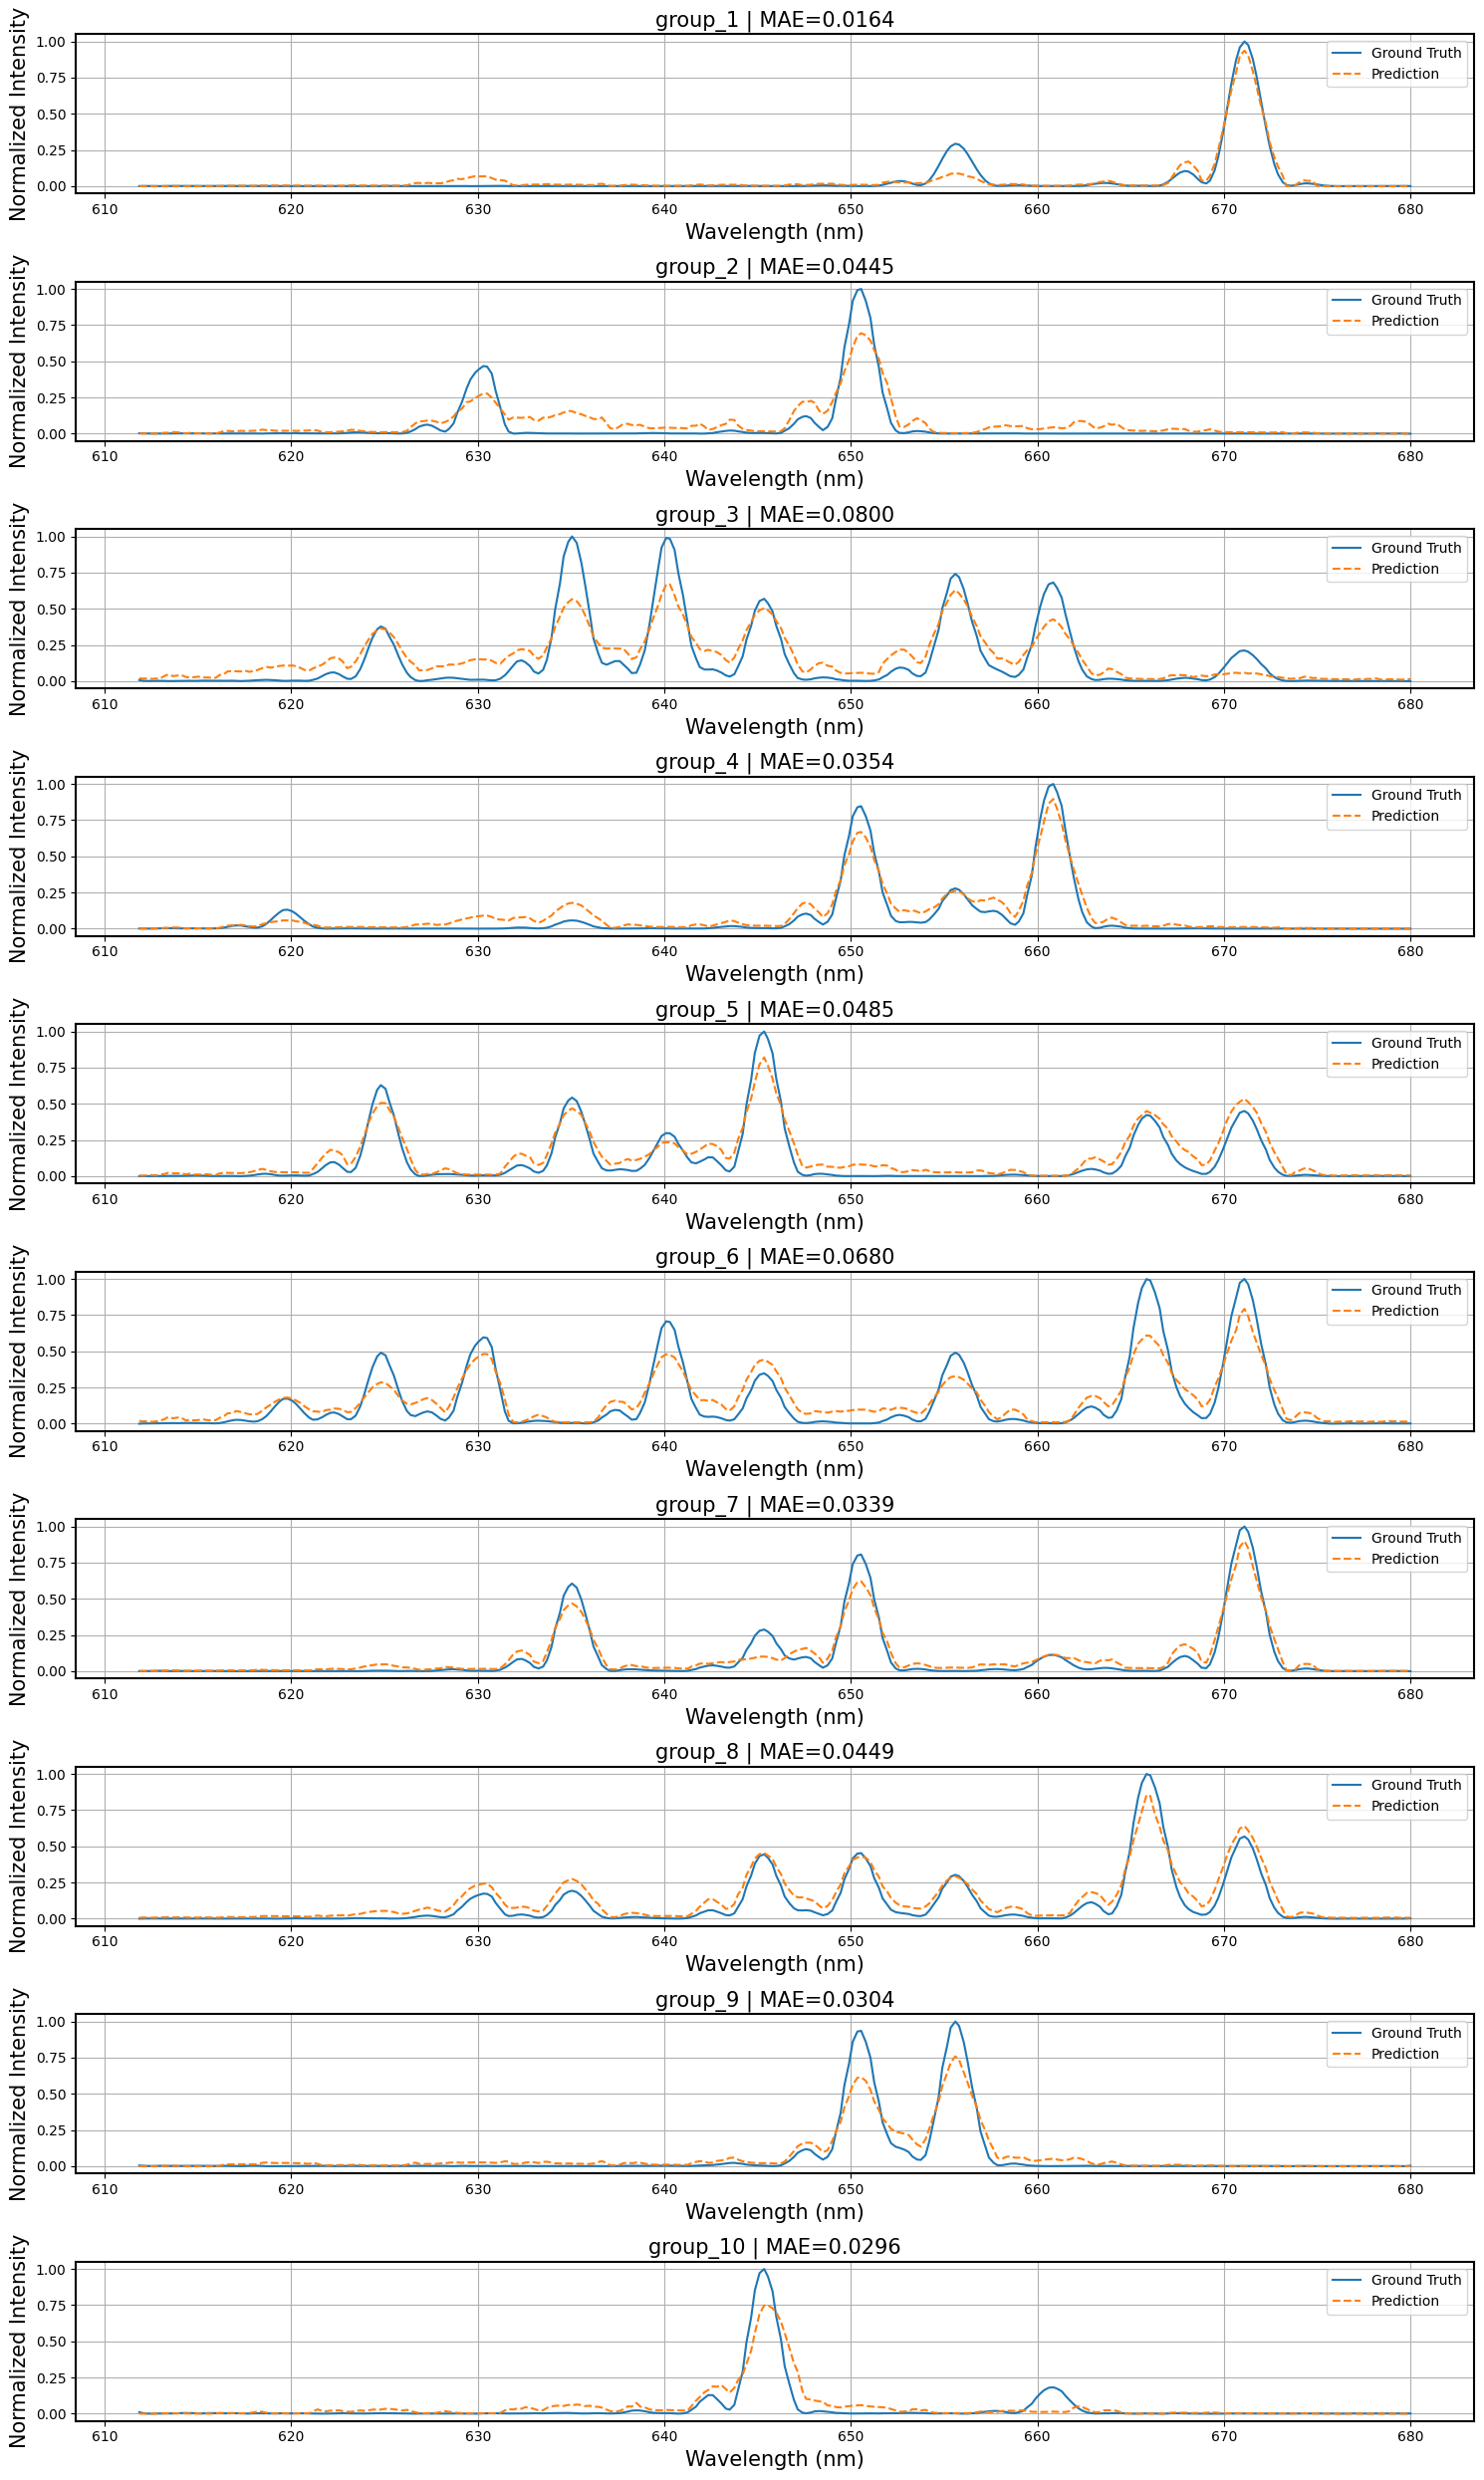

In [19]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ===== 路径 =====
test_file = os.path.join(ds_dir, "test2.h5")  # 改为test2.h5
best_model_path = os.path.join(ds_dir, "Resnet_training_checkpoints", "best_model.keras")
batch_size = 64

# ===== 1. 加载 test2.h5（注意：结构与 train.h5 不同）=====
with h5py.File(test_file, "r") as hf:
    print(f"Loading: {test_file}")
    print(f"Keys: {list(hf.keys())}")

    test_x = hf["img"][:].astype(np.float32)              # (N, 40, 400)
    test_y = hf["osa"][:].squeeze(-1).astype(np.float32)  # (N, 300)
    wavelength = hf["wavelength"][0]                     # 所有样本波长相同
    labels = [
        x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
        for x in hf["labels"][:]
    ]

# 与训练一致：加 channel 维 -> (N, 40, 400, 1)
if test_x.ndim == 3:
    test_x = np.expand_dims(test_x, axis=-1)

print(f"test_x: {test_x.shape}, test_y: {test_y.shape}")

# ===== 2. 加载最佳模型 =====
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model not found: {best_model_path}")

print(f"Loading model: {best_model_path}")
model = load_model(best_model_path)

# ===== 3. 预测 =====
predictions = model.predict(test_x, batch_size=batch_size, verbose=1)
if predictions.ndim == 3 and predictions.shape[-1] == 1:
    predictions = predictions.squeeze(-1)

# ===== 4. 指标 =====
mse = np.mean((predictions - test_y) ** 2)
mae = np.mean(np.abs(predictions - test_y))
print(f"\nTest MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")

per_sample_mae = np.mean(np.abs(predictions - test_y), axis=1)
for i in range(min(10, len(labels))):
    print(f"  [{i}] {labels[i]}: MAE={per_sample_mae[i]:.4f}")

# ===== 5. 可视化 =====
n_plot = min(10, len(test_y))
plt.figure(figsize=(15, n_plot * 2.5))
for i in range(n_plot):
    plt.subplot(n_plot, 1, i + 1)
    plt.plot(wavelength, test_y[i], label="Ground Truth")
    plt.plot(wavelength, predictions[i], "--", label="Prediction")
    plt.title(f"{labels[i]} | MAE={per_sample_mae[i]:.4f}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Intensity")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

## Test set 3

Loading: /content/drive/MyDrive/ucsc/MMI/8um/test3.h5
Keys: ['img', 'img_filenames', 'labels', 'osa', 'osa_filenames', 'peaks', 'wavelength']
test_x: (50, 40, 400, 1), test_y: (50, 300)
Loading model: /content/drive/MyDrive/ucsc/MMI/8um/Resnet_training_checkpoints/best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Test MSE: 0.006531
Test MAE: 0.055021
  [0] group_1: MAE=0.0970
  [1] group_2: MAE=0.0547
  [2] group_3: MAE=0.0619
  [3] group_4: MAE=0.0432
  [4] group_5: MAE=0.0593
  [5] group_6: MAE=0.0465
  [6] group_7: MAE=0.0690
  [7] group_8: MAE=0.0267
  [8] group_9: MAE=0.0303
  [9] group_10: MAE=0.0326


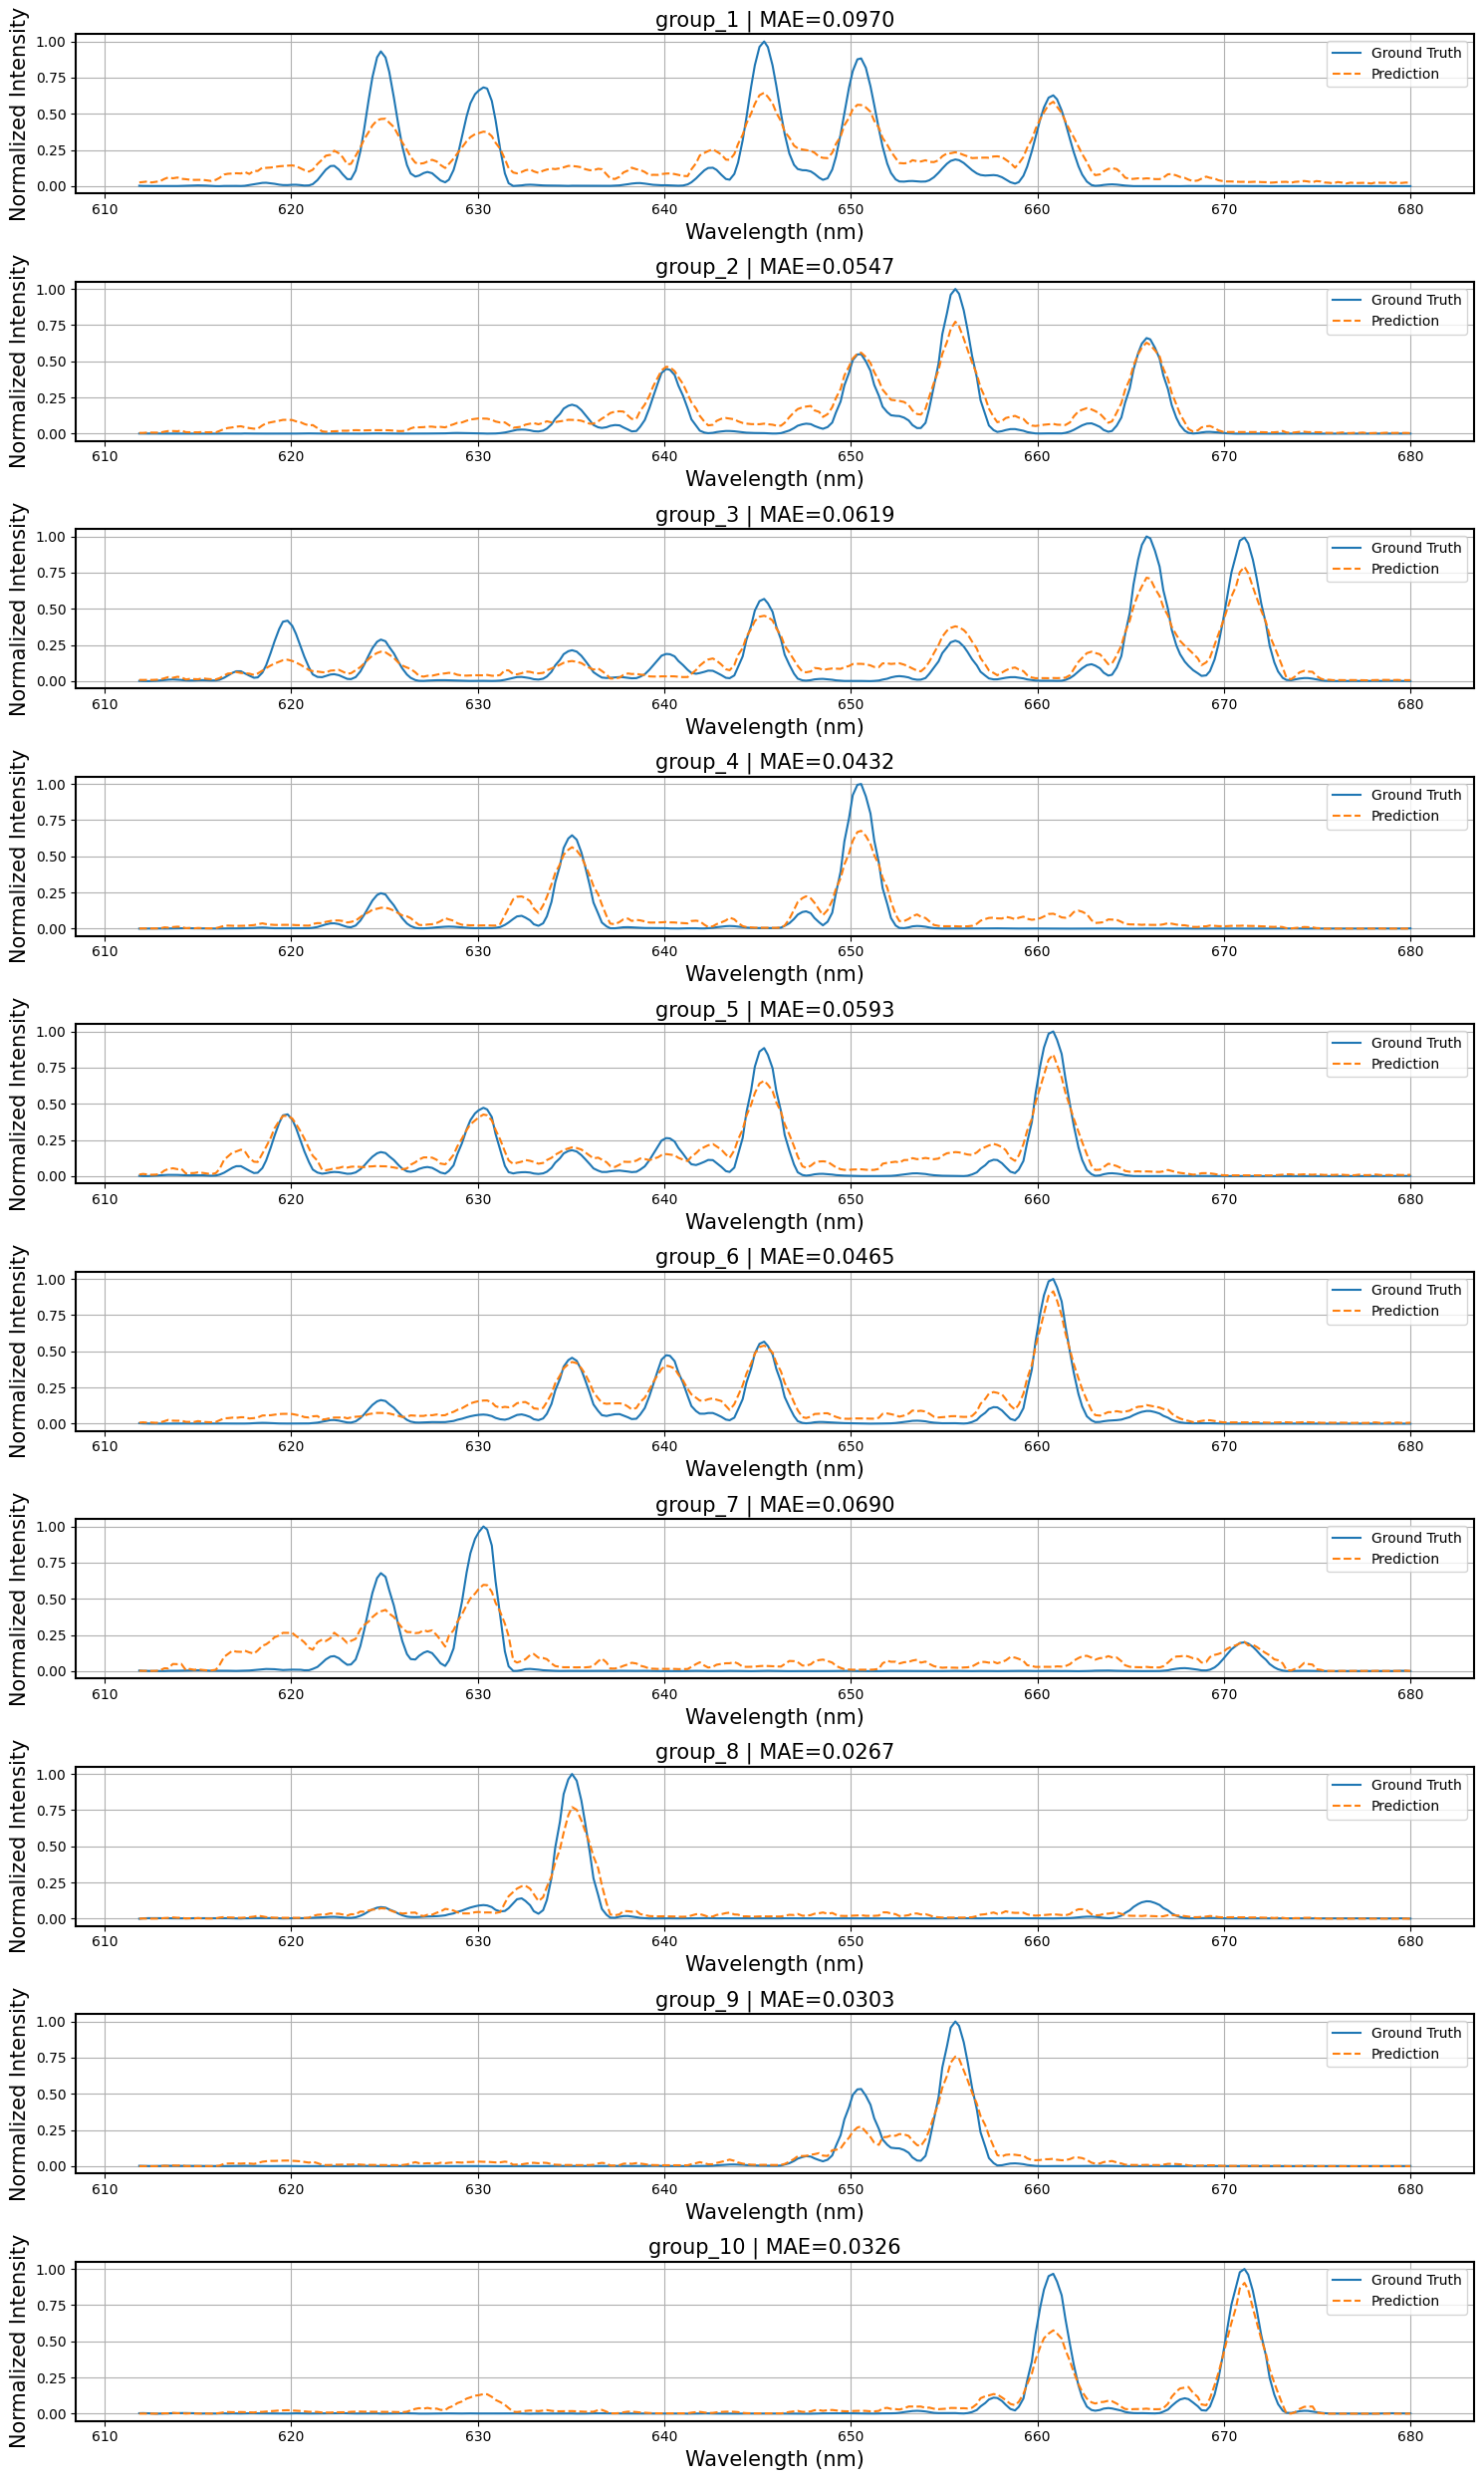

In [20]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ===== 路径 =====
test_file = os.path.join(ds_dir, "test3.h5")  # 改为test3.h5
best_model_path = os.path.join(ds_dir, "Resnet_training_checkpoints", "best_model.keras")
batch_size = 64

# ===== 1. 加载 test3.h5（注意：结构与 train.h5 不同）=====
with h5py.File(test_file, "r") as hf:
    print(f"Loading: {test_file}")
    print(f"Keys: {list(hf.keys())}")

    test_x = hf["img"][:].astype(np.float32)              # (N, 40, 400)
    test_y = hf["osa"][:].squeeze(-1).astype(np.float32)  # (N, 300)
    wavelength = hf["wavelength"][0]                     # 所有样本波长相同
    labels = [
        x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
        for x in hf["labels"][:]
    ]

# 与训练一致：加 channel 维 -> (N, 40, 400, 1)
if test_x.ndim == 3:
    test_x = np.expand_dims(test_x, axis=-1)

print(f"test_x: {test_x.shape}, test_y: {test_y.shape}")

# ===== 2. 加载最佳模型 =====
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model not found: {best_model_path}")

print(f"Loading model: {best_model_path}")
model = load_model(best_model_path)

# ===== 3. 预测 =====
predictions = model.predict(test_x, batch_size=batch_size, verbose=1)
if predictions.ndim == 3 and predictions.shape[-1] == 1:
    predictions = predictions.squeeze(-1)

# ===== 4. 指标 =====
mse = np.mean((predictions - test_y) ** 2)
mae = np.mean(np.abs(predictions - test_y))
print(f"\nTest MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")

per_sample_mae = np.mean(np.abs(predictions - test_y), axis=1)
for i in range(min(10, len(labels))):
    print(f"  [{i}] {labels[i]}: MAE={per_sample_mae[i]:.4f}")

# ===== 5. 可视化 =====
n_plot = min(10, len(test_y))
plt.figure(figsize=(15, n_plot * 2.5))
for i in range(n_plot):
    plt.subplot(n_plot, 1, i + 1)
    plt.plot(wavelength, test_y[i], label="Ground Truth")
    plt.plot(wavelength, predictions[i], "--", label="Prediction")
    plt.title(f"{labels[i]} | MAE={per_sample_mae[i]:.4f}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Intensity")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()